# Module 0 — Setup, Paths & Common Utilities

This notebook is a standalone module extracted from `cyclone_Model (1).ipynb`. Run this notebook independently. If it depends on an earlier module, it loads the saved artifact from `cyclone_artifacts/`.

In [ ]:
# Common bootstrap for standalone execution
import os, json, math, warnings, random, joblib
from pathlib import Path
from datetime import timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

IS_COLAB = "google.colab" in str(get_ipython())
DEVICE = None
try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except Exception:
    pass

WINDOW_SIZE = 5
LEAD_STEPS = 5
LEAD_HOURS = np.arange(1, LEAD_STEPS + 1) * 6
EARTH_RADIUS_KM = 6371.0

BASE_DIR = Path("/content") if IS_COLAB else Path(".")
ARTIFACT_DIR = BASE_DIR / "cyclone_artifacts"
MODEL_SAVE_DIR = BASE_DIR / "models"
DATA_SAVE_DIR = BASE_DIR / "data" / "processed"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
DATA_SAVE_DIR.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

IBTRACS_PATH = "/content/drive/MyDrive/IBTrACS.ALL.v04r01.nc" if IS_COLAB else "data/IBTrACS.ALL.v04r01.nc"
TCIR_PATH = "/content/drive/MyDrive/TCIR-CPAC_IO_SH.7z" if IS_COLAB else "data/TCIR-CPAC_IO_SH.7z"

print("Standalone bootstrap loaded.")
print("Colab:", IS_COLAB, "| Device:", DEVICE)
print("IBTrACS:", IBTRACS_PATH)
print("TCIR:", TCIR_PATH)
print("Artifacts:", ARTIFACT_DIR)

Mounted at /content/drive
Standalone bootstrap loaded.
Colab: True | Device: cpu
IBTrACS: /content/drive/MyDrive/IBTrACS.ALL.v04r01.nc
TCIR: /content/drive/MyDrive/TCIR-CPAC_IO_SH.7z
Artifacts: /content/cyclone_artifacts


In [ ]:
# ============================================================
# 0. INSTALLATION + IMPORTS
# ============================================================
%pip -q install xarray netCDF4 geopandas rasterio h5py py7zr joblib


from pathlib import Path
from datetime import timedelta # Import timedelta for resample_storm_track
import joblib # For saving/loading scikit-learn models

import xarray as xr
import geopandas as gpd

from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_COLAB = "google.colab" in str(get_ipython())



print("Colab:", IS_COLAB)
print("Device:", DEVICE)
print("Lead times:", LEAD_HOURS, "hours")

# Define model saving directory (adjust as needed for local vs. Colab)
if IS_COLAB:
    # Mount Google Drive if in Colab to save models persistently
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    MODEL_SAVE_DIR = "/content/drive/MyDrive/cyclone_models"
    DATA_SAVE_DIR = "/content/drive/MyDrive/cyclone_data"
else:
    MODEL_SAVE_DIR = "./models"
    DATA_SAVE_DIR = "./data/processed"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(DATA_SAVE_DIR, exist_ok=True)
print(f"Models will be saved to: {MODEL_SAVE_DIR}")
print(f"Processed data will be saved to: {DATA_SAVE_DIR}")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.7/492.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.9 MB/s eta 0:00:00
Colab: True
Device: cpu
Lead times: [ 6 12 18 24 30] hours
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models will be saved to: /content/drive/MyDrive/cyclone_models
Processed data will be saved to: /content/drive/MyDrive/cyclone_data


In [ ]:
def unwrap_longitude_difference(lon2, lon1):
    """
    Calculates the difference between two longitudes, correctly handling
    the -180/180 degree antimeridian wraparound.
    """
    dlon = lon2 - lon1
    # Normalize to -180 to 180 degrees
    dlon = (dlon + 180) % 360 - 180
    return dlon

def resample_storm_track(storm_df, freq='6H', gap_threshold=timedelta(hours=6, minutes=30)):
    if storm_df.empty:
        return []

    # Set ISO_TIME as index for resampling
    storm_df = storm_df.set_index('ISO_TIME').sort_index()

    # Resample to strict frequency, keeping only first values within each window
    # We use asfreq which fills missing times with NaNs.
    resampled_storm = storm_df.asfreq(freq)

    # Define a helper for interpolation logic, including LON unwrapping/wrapping
    def interpolate_segment(segment_df):
        if segment_df.empty:
            return segment_df

        # Interpolate numerical columns other than LON
        numerical_cols = ['LAT', 'USA_WIND', 'USA_PRES']
        for col in numerical_cols:
            if col in segment_df.columns:
                segment_df[col] = segment_df[col].interpolate(method='linear', limit_direction='both')

        # Handle USA_STATUS for categorical data
        if 'USA_STATUS' in segment_df.columns:
            segment_df['USA_STATUS'] = segment_df['USA_STATUS'].ffill().bfill()

        # Special handling for LON with unwrapping/wrapping for interpolation
        if 'LON' in segment_df.columns and segment_df['LON'].notna().any():
            # Temporarily unwrap longitude for linear interpolation
            # Choose the first valid longitude as a reference to keep values in a continuous range
            first_valid_lon = segment_df['LON'].dropna().iloc[0]
            unwrapped_lon = segment_df['LON'].apply(lambda x: (x - first_valid_lon + 180) % 360 - 180 + first_valid_lon if pd.notna(x) else np.nan)

            unwrapped_lon_interpolated = unwrapped_lon.interpolate(method='linear', limit_direction='both')

            # Wrap back to [-180, 180] range
            segment_df['LON'] = (unwrapped_lon_interpolated + 180) % 360 - 180

        return segment_df.dropna(subset=['LAT', 'LON', 'USA_WIND', 'USA_PRES', 'USA_STATUS'])

    # Calculate time differences between consecutive valid points to find gaps
    time_diffs = resampled_storm.index.to_series().diff()

    # Identify where gaps exceed the threshold
    # Use resampled_storm.index as Series for direct comparison with time_diffs.index
    gap_indices = resampled_storm.index[time_diffs > gap_threshold]
    gap_starts = gap_indices.tolist()

    split_segments = []
    current_start_idx = 0

    # If there are no gaps, process the entire storm as one segment
    if not gap_starts:
        processed_segment = interpolate_segment(resampled_storm.reset_index())
        if not processed_segment.empty and len(processed_segment) > 1:
            split_segments.append(processed_segment)
    else:
        # Split the storm into sub-tracks based on identified gaps
        for gap_time in gap_starts:
            # Get location of the gap in the resampled_storm index
            gap_idx = resampled_storm.index.get_loc(gap_time)

            # Extract segment before the gap
            sub_df = resampled_storm.iloc[current_start_idx : gap_idx]
            processed_segment = interpolate_segment(sub_df).reset_index()
            if not processed_segment.empty and len(processed_segment) > 1:
                split_segments.append(processed_segment)

            # Update start index for the next segment (after the gap)
            current_start_idx = gap_idx

        # Add the last segment after the last gap
        last_df = resampled_storm.iloc[current_start_idx : ]
        processed_segment = interpolate_segment(last_df).reset_index()
        if not processed_segment.empty and len(processed_segment) > 1:
            split_segments.append(processed_segment)

    # Assign a unique 'TRACK_ID' to each valid sub-track
    final_tracks = []
    track_id_counter = 0
    for segment_df in split_segments:
        # Ensure segment_df has 'SID' column before trying to access it
        if not segment_df.empty and 'SID' in segment_df.columns:
            segment_df['TRACK_ID'] = f"{segment_df['SID'].iloc[0].astype(int)}_{track_id_counter}"
            final_tracks.append(segment_df)
            track_id_counter += 1

    return final_tracks

def calculate_local_displacements(lat1, lon1, lat2, lon2, earth_radius_km=6371.0):
    """
    Calculates local displacements (dx, dy) in kilometers between two points
    using the mean latitude for dx. This corrects for the distortion caused
    by longitude lines converging at the poles.

    Args:
        lat1, lon1 (float/array-like): Latitude and longitude of the first point (degrees).
        lat2, lon2 (float/array-like): Latitude and longitude of the second point (degrees).
        earth_radius_km (float): Earth's radius in kilometers.

    Returns:
        tuple: (dx, dy) in kilometers.
    """
    # Convert degrees to radians
    lat1_rad, lon1_rad = np.deg2rad(lat1), np.deg2rad(lon1)
    lat2_rad = np.deg2rad(lat2)

    dlat_rad = lat2_rad - lat1_rad

    # Use the unwrapped longitude difference in degrees, then convert to radians
    dlon_deg = unwrap_longitude_difference(lon2, lon1)
    dlon_rad = np.deg2rad(dlon_deg)

    # Mean latitude for dx calculation
    mean_lat_rad = (lat1_rad + lat2_rad) / 2.0

    dy_km = earth_radius_km * dlat_rad
    dx_km = earth_radius_km * dlon_rad * np.cos(mean_lat_rad)

    return dx_km, dy_km

## Module 1 — IBTrACS ingestion, cleaning, feature engineering, GroupKFold models and 30-hour forecast

In [ ]:
import xarray as xr
# ============================================================
# 2. MODULE 1 — IBTRACS INGESTION + CLEANING
# ============================================================
def make_synthetic_tracks(n_storms=30, points_per_storm=28):
    rows = []
    for s in range(n_storms):
        sid = f"SYN_{s:03d}"
        lat = np.random.uniform(7, 20)
        lon = np.random.uniform(55, 95)
        wind = np.random.uniform(20, 55)
        pressure = 1000 - 0.8 * wind + np.random.normal(0, 3)
        for t in range(points_per_storm):
            heading = np.random.normal(np.deg2rad(45), np.deg2rad(12))
            speed = max(8, np.random.normal(45, 10))
            dx = speed * np.sin(heading)
            dy = speed * np.cos(heading)
            lat += dy / 111.0
            lon += dx / (111.0 * np.cos(np.deg2rad(max(1, lat))))
            wind = np.clip(wind + np.random.normal(1.0, 2.5), 15, 125)
            pressure = np.clip(1012 - 0.9 * wind + np.random.normal(0, 2), 880, 1015)
            status = (
                "DD" if wind < 34 else
                "CS" if wind < 48 else
                "SCS" if wind < 64 else
                "VSCS"
            )
            # Ensure ISO_TIME is a standard datetime object, floored to hour for cleaner synthetic timestamps
            iso_time = pd.Timestamp("2010-01-01") + pd.Timedelta(hours=6*t)
            rows.append([sid, iso_time.floor('H'),
                         lat, lon, wind, pressure, status])
    return pd.DataFrame(rows, columns=[
        "SID","ISO_TIME","LAT","LON","USA_WIND","USA_PRES","USA_STATUS"
    ])

def load_ibtracs_nio(path):
    if not os.path.exists(path):
        print("IBTRACS file not found — using synthetic NIO tracks.")
        return make_synthetic_tracks()

    # Open with decode_times=True to get proper datetime objects for 'time'
    ds = xr.open_dataset(path, decode_times=True)

    # Always use USA lat/lon for track consistency
    needed_vars = ["usa_lat", "usa_lon"]

    wind_src_agency = "USA"
    pres_src_agency = "USA"
    status_src_agency = "USA"

    # Prioritize IMD (New Delhi) data for wind/pressure if available
    if "new_delhi_wind" in ds.variables and "new_delhi_pres" in ds.variables:
        needed_vars.append("new_delhi_wind")
        needed_vars.append("new_delhi_pres")
        wind_src_agency = "NEW_DELHI"
        pres_src_agency = "NEW_DELHI"
        if "new_delhi_status" in ds.variables:
            needed_vars.append("new_delhi_status")
            status_src_agency = "NEW_DELHI"
        else:
            needed_vars.append("usa_status") # Fallback for status
            print("New Delhi status not found, defaulting to USA_STATUS.")
        print(f"Using NEW_DELHI wind/pres data.")
    else:
        needed_vars.append("usa_wind")
        needed_vars.append("usa_pres")
        needed_vars.append("usa_status")
        print(f"NEW_DELHI wind/pres not found, defaulting to USA data.")
        print(f"Note: USA wind (1-min avg) vs. IMD wind (3-min avg) may differ. "
              f"A conversion factor might be needed (e.g., *0.88 for 3-min to 1-min).")

    # 'storm' and 'time' are typically coordinates or variables after decode_times=True
    # xarray.to_dataframe() will put coordinates (like 'time' and 'storm') as index levels.
    # We need to reset_index to make them columns.
    df_raw = ds[needed_vars].to_dataframe().reset_index()

    # Rename columns to standard names for downstream consistency
    column_mapping = {
        "storm": "SID",
        "time": "ISO_TIME",
        "usa_lat": "LAT",
        "usa_lon": "LON"
    }

    # Dynamically add wind/pres/status mapping based on source agency
    if wind_src_agency == "NEW_DELHI":
        column_mapping["new_delhi_wind"] = "USA_WIND" # Keep target name consistent for downstream code
    else: # USA
        column_mapping["usa_wind"] = "USA_WIND"

    if pres_src_agency == "NEW_DELHI":
        column_mapping["new_delhi_pres"] = "USA_PRES"
    else: # USA
        column_mapping["usa_pres"] = "USA_PRES"

    if status_src_agency == "NEW_DELHI":
        column_mapping["new_delhi_status"] = "USA_STATUS"
    else: # USA
        column_mapping["usa_status"] = "USA_STATUS"

    df = df_raw.rename(columns=column_mapping)

    # Convert to numeric, handle fill values for essential columns
    for c in ["LAT","LON","USA_WIND","USA_PRES"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].replace([-9999, -999, -99], np.nan)

    # Ensure ISO_TIME is a proper datetime object for resampling
    df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"])

    # Drop rows with NaN in essential columns before resampling
    df = df.dropna(subset=["LAT", "LON", "USA_WIND", "USA_PRES", "USA_STATUS"])

    # Group by SID and apply resample_storm_track
    # resample_storm_track now returns a list of DataFrames, each with a unique TRACK_ID
    processed_tracks_list = []
    for sid, storm_df in df.groupby("SID"):
        # The resample_storm_track returns a list of dataframes (sub-tracks)
        sub_tracks = resample_storm_track(storm_df, freq='6H')
        processed_tracks_list.extend(sub_tracks)

    # Concatenate all processed tracks back into a single DataFrame
    df_resampled = pd.concat(processed_tracks_list, ignore_index=True)

    # Sort by SID and ISO_TIME
    df_resampled = df_resampled.sort_values(by=["SID", "ISO_TIME"]).reset_index(drop=True)

    print(f"Loaded and processed {len(np.unique(df_resampled['SID']))} unique storms, "
          f"resulting in {len(df_resampled)} data points and {len(np.unique(df_resampled['TRACK_ID']))} sub-tracks.")
    return df_resampled

df = load_ibtracs_nio(IBTRACS_PATH)

NEW_DELHI wind/pres not found, defaulting to USA data.
Note: USA wind (1-min avg) vs. IMD wind (3-min avg) may differ. A conversion factor might be needed (e.g., *0.88 for 3-min to 1-min).
Loaded and processed 3324 unique storms, resulting in 89245 data points and 3323 sub-tracks.


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# 3. MODULE 1 — KINEMATICS + SLIDING WINDOWS
# ============================================================

# We will work directly with LAT/LON and calculate displacements using the `calculate_local_displacements` helper.

# Calculate local displacements (dx_km, dy_km) for each step relative to the previous step
# Group by TRACK_ID instead of SID to respect sub-track boundaries
df['prev_LAT'] = df.groupby('TRACK_ID')['LAT'].shift(1)
df['prev_LON'] = df.groupby('TRACK_ID')['LON'].shift(1)

# Vectorized calculation of dx_km and dy_km
valid_indices = df['prev_LAT'].notna() # Only calculate for points that have a previous point
dx_vals, dy_vals = calculate_local_displacements(
    df.loc[valid_indices, 'prev_LAT'], df.loc[valid_indices, 'prev_LON'],
    df.loc[valid_indices, 'LAT'], df.loc[valid_indices, 'LON'],
    earth_radius_km=EARTH_RADIUS_KM
)
df.loc[valid_indices, 'dx_km'] = dx_vals
df.loc[valid_indices, 'dy_km'] = dy_vals

# For the first point of each storm (where prev_LAT/LON are NaN), dx_km and dy_km are 0
df['dx_km'] = df['dx_km'].fillna(0)
df['dy_km'] = df['dy_km'].fillna(0)

# Drop temporary columns
df.drop(columns=['prev_LAT', 'prev_LON'], inplace=True)

# Calculate instantaneous distance and heading from dx_km, dy_km
df["dist_km"] = np.hypot(df['dx_km'], df['dy_km'])
df["heading_rad"] = np.arctan2(df['dy_km'], df['dx_km']) # Note: arctan2(y, x)
df["heading_rad"] = np.mod(df["heading_rad"], 2 * np.pi)

# Add sin/cos of heading as input features
df["sin_heading"] = np.sin(df["heading_rad"])
df["cos_heading"] = np.cos(df["heading_rad"])

# Add lag features for wind and pressure change
# Group by TRACK_ID instead of SID
df['USA_WIND_LAG1'] = df.groupby('TRACK_ID')['USA_WIND'].shift(1)
df['USA_PRES_LAG1'] = df.groupby('TRACK_ID')['USA_PRES'].shift(1)
df['USA_WIND_CHANGE'] = df['USA_WIND'] - df['USA_WIND_LAG1']
df['USA_PRES_CHANGE'] = df['USA_PRES'] - df['USA_PRES_LAG1']

# Fill NaNs created by shift for the first point of each storm with 0 (no change)
df['USA_WIND_CHANGE'] = df['USA_WIND_CHANGE'].fillna(0)
df['USA_PRES_CHANGE'] = df['USA_PRES_CHANGE'].fillna(0)

# Define feature columns - these will be inputs to the model
FEATURE_COLS = [
    "LAT", "LON", "USA_WIND", "USA_PRES",
    "dx_km", "dy_km", "dist_km", "sin_heading", "cos_heading",
    "USA_WIND_CHANGE", "USA_PRES_CHANGE"
]

def build_forecast_samples(track_df, window=5, max_lead=5):
    X, Y_dist_step, Y_heading_step, Y_wind, Y_pres, groups, meta = [], [], [], [], [], [], []
    # Group by TRACK_ID instead of SID to respect sub-track boundaries
    for track_id, g in track_df.groupby("TRACK_ID"):
        # Ensure 'ISO_TIME' is sorted for correct windowing and lead steps
        g = g.sort_values("ISO_TIME").reset_index(drop=True)

        if len(g) < window + max_lead:
            continue

        # Extract values for features and potential targets
        # We need dx_km, dy_km, USA_WIND, USA_PRES for target calculations
        g_vals_for_targets = g[["dx_km", "dy_km", "USA_WIND", "USA_PRES"]].to_numpy(float)
        g_vals_for_features = g[FEATURE_COLS].to_numpy(float)

        for i in range(window, len(g) - max_lead + 1):
            # Features are the window-size historical inputs
            hist = g_vals_for_features[i-window:i].reshape(-1)
            X.append(hist)

            # Targets are single-step displacements (dist, heading) and instantaneous wind/pressure
            lead_targets_dist_step, lead_targets_heading_step, lead_targets_vmax, lead_targets_pres = [], [], [], []

            for h in range(1, max_lead + 1):
                # Get single-step dx_km and dy_km for the current lead step
                dx_step = g_vals_for_targets[i+h-1, 0] # dx_km
                dy_step = g_vals_for_targets[i+h-1, 1] # dy_km

                dist_step = np.hypot(dx_step, dy_step)
                # Heading is arctan2(dy, dx) and should be normalized to [0, 2pi)
                heading_step = np.mod(np.arctan2(dy_step, dx_step), 2 * np.pi)

                lead_targets_dist_step.append(dist_step)
                lead_targets_heading_step.append(heading_step)
                lead_targets_vmax.append(g_vals_for_targets[i+h-1, 2]) # USA_WIND
                lead_targets_pres.append(g_vals_for_targets[i+h-1, 3]) # USA_PRES

            Y_dist_step.append(lead_targets_dist_step)
            Y_heading_step.append(lead_targets_heading_step)
            Y_wind.append(lead_targets_vmax)
            Y_pres.append(lead_targets_pres)

            groups.append(track_id) # Group by TRACK_ID for GroupKFold
            meta.append({
                "SID": g["SID"].iloc[0], # Keep original SID for reference
                "TRACK_ID": track_id, # Add TRACK_ID to meta for clarity
                "origin_idx": i-1,
                "origin_time": g.loc[i-1, "ISO_TIME"],
                "origin_lat": g.loc[i-1, "LAT"],
                "origin_lon": g.loc[i-1, "LON"]
            })

    # Stack all targets into a single Y array: (n_samples, LEAD_STEPS, n_target_dims)
    # Target dims: [dist_km, heading_rad, vmax_kt, pressure_hpa]
    Y = np.stack([
        np.asarray(Y_dist_step),
        np.asarray(Y_heading_step),
        np.asarray(Y_wind),
        np.asarray(Y_pres)
    ], axis=-1)

    return np.asarray(X), Y, np.asarray(groups), pd.DataFrame(meta)

# Use TRACK_ID as groups for build_forecast_samples
X, Y, groups, sample_meta = build_forecast_samples(df, WINDOW_SIZE, LEAD_STEPS)
print("X:", X.shape, "Y:", Y.shape, "unique tracks:", len(np.unique(groups)))

X: (60279, 55) Y: (60279, 5, 4) unique tracks: 2967


In [ ]:
print('--- dist_km Validation ---')
# Print max and describe dist_km
print(f"Max dist_km: {df['dist_km'].max():.2f} km")
print(df['dist_km'].describe())

# Add an assertion or warning for dist_km above a sane threshold
MAX_SANCTIONED_DIST_KM = 400.0 # Define a sane threshold for 6-hour displacement

if (df['dist_km'] > MAX_SANCTIONED_DIST_KM).any():
    problematic_rows = df[df['dist_km'] > MAX_SANCTIONED_DIST_KM]
    print(f"\nWARNING: Found {len(problematic_rows)} instances where dist_km > {MAX_SANCTIONED_DIST_KM} km.")
    print("These might indicate remaining data issues or extremely fast-moving storms.")
    display(problematic_rows[['SID', 'ISO_TIME', 'LAT', 'LON', 'dx_km', 'dy_km', 'dist_km']].head())
else:
    print(f"\nAll dist_km values are within the sane threshold of {MAX_SANCTIONED_DIST_KM} km.")

--- dist_km Validation ---
Max dist_km: 7101.05 km
count    89245.000000
mean       119.901240
std        169.068332
min          0.000000
25%         61.446340
50%         98.457139
75%        141.296387
max       7101.048257
Name: dist_km, dtype: float64

These might indicate remaining data issues or extremely fast-moving storms.


,SID,ISO_TIME,LAT,LON,dx_km,dy_km,dist_km
1,65.0,1854-09-08 18:00:00.000040240,31.600000,-81.099998,-241.227799,400.301697,467.367414
5,427.0,1869-09-09 00:00:00.000040256,42.799999,-71.099998,126.261019,444.779480,462.353361
7,451.0,1870-09-12 00:00:00.000040256,41.500000,-57.399994,-422.206731,2479.646973,2515.334497
14,552.0,1874-09-30 18:00:00.000040256,46.000000,-68.000000,1031.088630,1467.772949,1793.739444
16,562.0,1875-09-14 06:00:00.000040256,23.400000,-82.399994,-401.512613,266.867676,482.110708


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold # Import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report,
)

# ============================================================
# 4. MODULE 1 — GROUPKFOLD DIRECT MODELS
# ============================================================
def get_imd_category(vmax_knots):
    if pd.isna(vmax_knots): return "Unknown"
    if vmax_knots < 17: return "Low Pressure Area" # Corrected based on IMD classification
    if vmax_knots < 28: return "Depression"
    if vmax_knots < 34: return "Deep Depression"
    if vmax_knots < 48: return "Cyclonic Storm"
    if vmax_knots < 64: return "Severe Cyclonic Storm"
    if vmax_knots < 90: return "Very Severe Cyclonic Storm"
    if vmax_knots < 120: return "Extremely Severe Cyclonic Storm"
    return "Super Cyclonic Storm"

def fit_gbr():
    return GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.03,
        max_depth=3, subsample=0.8, random_state=SEED
    )


def train_module1_groupkfold(X, Y, groups, n_splits=5):
    n_splits = min(n_splits, len(np.unique(groups)))

    # Determine stratification labels from the last point's wind in X
    # USA_WIND is at index 2 in FEATURE_COLS
    # So, for the last point (WINDOW_SIZE-1), it's at index (WINDOW_SIZE-1)*len(FEATURE_COLS) + 2
    wind_idx_in_X_row = (WINDOW_SIZE - 1) * len(FEATURE_COLS) + FEATURE_COLS.index("USA_WIND")
    y_stratify = np.array([get_imd_category(w) for w in X[:, wind_idx_in_X_row]])

    # Use StratifiedGroupKFold for stratification
    gkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    # Split using the stratification labels
    tr, va = next(gkf.split(X, y_stratify, groups=groups))

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X[tr])
    Xva = scaler.transform(X[va])

    models = {}
    metrics = []

    for lead_idx, lead_h in enumerate(LEAD_HOURS):
        lead_models = {}
        # The targets in Y are now: [dist_km, heading_rad, vmax_kt, pressure_hpa]
        target_names = ["dist_km", "heading_rad", "vmax_kt", "pressure_hpa"]
        for target_col_idx, target_name in enumerate(target_names):
            model = fit_gbr()
            model.fit(Xtr, Y[tr, lead_idx, target_col_idx])
            pred = model.predict(Xva)
            true = Y[va, lead_idx, target_col_idx]
            lead_models[target_name] = model
            metrics.append([
                lead_h, target_name,
                mean_absolute_error(true, pred),
                mean_squared_error(true, pred) ** 0.5
            ])
        models[lead_h] = lead_models

    # For the RF classifier, we are using vmax_kt, which is Y[:,0,2]
    # If Y has changed its target order, update this index too.
    # Now vmax_kt is at index 2 in the new Y structure.
    y_status = np.array([get_imd_category(v) for v in Y[:,0,2]])
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=4,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    )
    rf.fit(Xtr, y_status[tr])
    status_pred = rf.predict(Xva)

    print("Unseen-storm status classification:")
    print(classification_report(y_status[va], status_pred, zero_division=0))

    return {
        "scaler": scaler, "gbr": models, "rf_status": rf,
        "train_idx": tr, "val_idx": va,
        "metrics": pd.DataFrame(metrics, columns=["lead_h","target","MAE","RMSE"])
    }

module1 = train_module1_groupkfold(X, Y, groups)
display(module1["metrics"])


Unseen-storm status classification:
                                 precision    recall  f1-score   support

                 Cyclonic Storm       0.86      0.79      0.82      3156
                Deep Depression       0.65      0.73      0.69      1213
                     Depression       0.83      0.84      0.83      1237
Extremely Severe Cyclonic Storm       0.83      0.85      0.84      1574
              Low Pressure Area       0.71      0.78      0.74        68
          Severe Cyclonic Storm       0.76      0.80      0.78      2150
           Super Cyclonic Storm       0.81      0.83      0.82       509
     Very Severe Cyclonic Storm       0.84      0.82      0.83      2229

                       accuracy                           0.80     12136
                      macro avg       0.78      0.80      0.79     12136
                   weighted avg       0.81      0.80      0.80     12136



,lead_h,target,MAE,RMSE
0,6,dist_km,28.282982,112.913182
1,6,heading_rad,0.378856,0.773705
2,6,vmax_kt,3.498674,5.068081
3,6,pressure_hpa,2.524404,3.995543
4,12,dist_km,34.858282,115.836344
5,12,heading_rad,0.516196,0.914966
6,12,vmax_kt,6.095698,8.752217
7,12,pressure_hpa,4.350504,6.726761
8,18,dist_km,40.332446,114.140764
9,18,heading_rad,0.606840,0.997668


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# 5. MODULE 1 — AUTOREGRESSIVE 30-HOUR ROLLOUT + CLIPER BASELINE
# ============================================================
def make_feature_row(lat, lon, wind, pressure, dx, dy):
    dist = float(np.hypot(dx, dy))
    # Heading is arctan2(dy, dx) not (dx, dy) for standard math library
    heading = float(np.mod(np.arctan2(dy, dx), 2*np.pi))
    # Ensure the feature vector matches FEATURE_COLS order, excluding dist_km, sin_heading, cos_heading
    # as these are derived or calculated within make_feature_row for the new point.
    # The full FEATURE_COLS is ["LAT", "LON", "USA_WIND", "USA_PRES", "dx_km", "dy_km", "dist_km", "sin_heading", "cos_heading", "USA_WIND_CHANGE", "USA_PRES_CHANGE"]
    # The window 'hist' will contain 5 such rows, flattened. So, we need to provide the raw values to update the history.
    # For simplicity, let's assume the order expected by the history is LAT, LON, WIND, PRES, DX, DY
    return np.array([lat, lon, wind, pressure, dx, dy, dist, np.sin(heading), np.cos(heading), 0, 0], dtype=float) # Last two are changes, assumed 0 for new point

def latlon_from_displacements(lat_prev, lon_prev, dx_km_step, dy_km_step, earth_radius_km=6371.0):
    """
    Converts a displacement (dx_km_step, dy_km_step) from a previous point
    (lat_prev, lon_prev) back to a new latitude and longitude (lat_new, lon_new).
    This is an inverse approximation of calculate_local_displacements.
    """
    lat_prev_rad = np.deg2rad(lat_prev)
    lon_prev_rad = np.deg2rad(lon_prev)

    # Calculate dlat (change in latitude)
    dlat_rad = dy_km_step / earth_radius_km
    lat_new_rad = lat_prev_rad + dlat_rad

    # For dlon (change in longitude), use the new latitude for the cosine factor
    # to improve accuracy in the inverse projection.
    cos_lat_factor = np.cos(lat_new_rad)
    if np.abs(cos_lat_factor) < 1e-9: # Avoid division by zero near poles
        dlon_rad = 0.0
    else:
        dlon_rad = dx_km_step / (earth_radius_km * cos_lat_factor)
    lon_new_rad = lon_prev_rad + dlon_rad

    # Convert back to degrees and wrap longitude to [-180, 180]
    lon_new_deg = np.rad2deg(lon_new_rad)
    lon_new_deg = (lon_new_deg + 180) % 360 - 180

    return np.rad2deg(lat_new_rad), lon_new_deg

def autoregressive_rollout(models, history_rows, n_steps=5):
    hist = np.asarray(history_rows, dtype=float).copy()
    out = []
    for step in range(n_steps):
        current_lead_h = (step + 1) * 6 # e.g., 6, 12, 18, 24, 30

        # Reshape to (1, -1) for scaler, as it expects a 2D array [n_samples, n_features]
        Xw = models["scaler"].transform(hist.reshape(1,-1))

        # Predict dist_km and heading_rad, then convert to dx_km and dy_km
        # Access models using the correct lead hour and target names
        one = models["gbr"][current_lead_h]["dist_km"].predict(Xw)[0] # Predicted distance in km
        head = models["gbr"][current_lead_h]["heading_rad"].predict(Xw)[0] # Predicted heading in radians
        wind = models["gbr"][current_lead_h]["vmax_kt"].predict(Xw)[0]
        pres = models["gbr"][current_lead_h]["pressure_hpa"].predict(Xw)[0]

        dx = one * np.cos(head)
        dy = one * np.sin(head)

        # Current position is the last point in the history window
        current_lat = hist[-1, 0]  # Access LAT from FEATURE_COLS
        current_lon = hist[-1, 1]  # Access LON from FEATURE_COLS

        # Convert predicted dx, dy (km) to new lat, lon
        lat_new, lon_new = latlon_from_displacements(current_lat, current_lon, dx, dy)

        # Update history with the new point. make_feature_row should now receive lat_new, lon_new.
        # Need to reconstruct the full feature vector as expected by X
        # FEATURE_COLS = ["LAT", "LON", "USA_WIND", "USA_PRES", "dx_km", "dy_km", "dist_km", "sin_heading", "cos_heading", "USA_WIND_CHANGE", "USA_PRES_CHANGE"]

        # Calculate wind/pressure change for the new feature row
        # Previous wind and pressure are from the last row of 'hist' (index 2 and 3 respectively in FEATURE_COLS)
        prev_wind = hist[-1, 2]
        prev_pres = hist[-1, 3]
        wind_change = wind - prev_wind
        pres_change = pres - prev_pres

        new_feature_values = np.array([
            lat_new, lon_new, wind, pres, dx, dy,
            one, np.sin(head), np.cos(head), wind_change, pres_change # Corrected changes
        ], dtype=float)

        # Correctly update the sliding window history: remove the oldest row, add the new one
        hist = np.vstack([hist[1:], new_feature_values.reshape(1, -1)])

        out.append({
            "lead_h": current_lead_h,
            "lat": float(lat_new), "lon": float(lon_new),
            "dist_km": float(one), "heading_rad": float(head),
            "vmax_kt": float(wind), "pressure_hpa": float(pres),
            "category": get_imd_category(wind)
        })
    return pd.DataFrame(out)

def cliper_style_forecast(history_rows, climatology):
    hist = np.asarray(history_rows, dtype=float)

    # Start from the last known position in the history window
    current_lat = hist[-1, 0]  # LAT
    current_lon = hist[-1, 1]  # LON

    result = []
    for step, lead_h in enumerate(LEAD_HOURS):
        clim = climatology.get(lead_h, {})

        # dx, dy from climatology and persistence (these are single-step displacements in km)
        # The original code's `dx` and `dy` from climatology might be cumulative,
        # but given `x += dx; y += dy;`, it seems to treat them as step-wise.
        # Assuming `clim.get("dx", 0)` is a step-wise displacement for consistency with AR model.
        dx = 0.5 * hist[-1, 4] + 0.5 * clim.get("dx", hist[-1, 4]) # Use last step dx_km
        dy = 0.5 * hist[-1, 5] + 0.5 * clim.get("dy", hist[-1, 5]) # Use last step dy_km

        # Apply displacement to current lat/lon to get new lat/lon
        current_lat, current_lon = latlon_from_displacements(current_lat, current_lon, dx, dy)

        result.append({"lead_h":lead_h,"lat":float(current_lat),"lon":float(current_lon)})
    return pd.DataFrame(result)

tr_idx = module1["train_idx"]
climatology = {}
for lead_h in LEAD_HOURS:
    j = lead_h//6 - 1


    avg_dist = np.mean(Y[tr_idx, j, 0]) if len(Y[tr_idx, j, 0]) > 0 else 0
    avg_heading = np.mean(Y[tr_idx, j, 1]) if len(Y[tr_idx, j, 1]) > 0 else 0

    climatology[lead_h] = {
        "dx": float(avg_dist * np.sin(avg_heading)),
        "dy": float(avg_dist * np.cos(avg_heading))
    }

sample = module1["val_idx"][0]
history = X[sample].reshape(WINDOW_SIZE, len(FEATURE_COLS))
rollout = autoregressive_rollout(module1, history, LEAD_STEPS)
cliper = cliper_style_forecast(history, climatology)

print("30-hour autoregressive forecast:")
display(rollout)


30-hour autoregressive forecast:


,lead_h,lat,lon,dist_km,heading_rad,vmax_kt,pressure_hpa,category
0,6,18.900984,-111.413163,132.044861,2.510165,37.471719,1002.888190,Cyclonic Storm
1,12,19.599565,-112.380914,127.713311,2.487768,40.987512,1000.577979,Cyclonic Storm
2,18,20.293685,-113.306894,123.626387,2.467330,49.628021,995.754212,Severe Cyclonic Storm
3,24,21.010675,-114.157133,118.934433,2.406935,61.840013,987.173860,Severe Cyclonic Storm
4,30,21.706459,-114.965969,113.877995,2.394661,72.636313,976.232604,Very Severe Cyclonic Storm


In [ ]:
# Save outputs so later modules can run in a separate notebook/kernel.
module1_state = {
    "df": df,
    "X": X,
    "Y": Y,
    "groups": groups,
    "sample_meta": sample_meta,
    "module1": module1,
    "rollout": rollout,
    "cliper": cliper,
    "climatology": climatology,
    "FEATURE_COLS": FEATURE_COLS,
}
joblib.dump(module1_state, ARTIFACT_DIR / "module1_state.joblib")
print("Saved:", ARTIFACT_DIR / "module1_state.joblib")


Saved: /content/cyclone_artifacts/module1_state.joblib


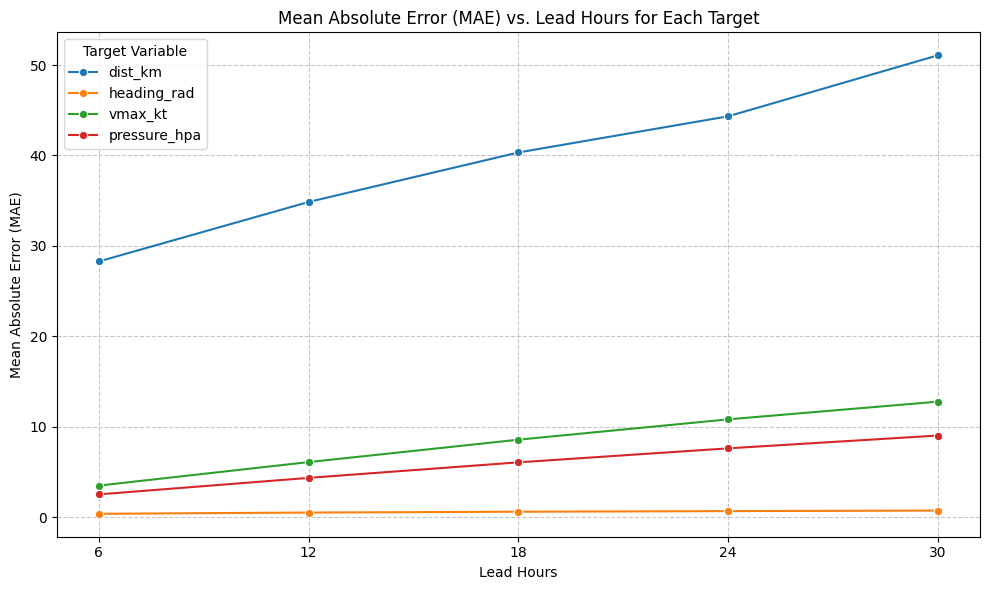

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_df = module1_state["module1"]["metrics"]

plt.figure(figsize=(10, 6))
sns.lineplot(data=metrics_df, x='lead_h', y='MAE', hue='target', marker='o')
plt.title('Mean Absolute Error (MAE) vs. Lead Hours for Each Target')
plt.xlabel('Lead Hours')
plt.ylabel('Mean Absolute Error (MAE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Target Variable')
plt.xticks(LEAD_HOURS) # Ensure x-axis ticks are at actual lead hours
plt.tight_layout()
plt.show()

In [ ]:
metrics_df_final = module1["metrics"].copy()
metrics_df_final["MSE"] = metrics_df_final["RMSE"]**2
display(metrics_df_final)

,lead_h,target,MAE,RMSE,MSE
0,6,dist_km,28.282982,112.913182,12749.386779
1,6,heading_rad,0.378856,0.773705,0.598620
2,6,vmax_kt,3.498674,5.068081,25.685448
3,6,pressure_hpa,2.524404,3.995543,15.964360
4,12,dist_km,34.858282,115.836344,13418.058525
5,12,heading_rad,0.516196,0.914966,0.837162
6,12,vmax_kt,6.095698,8.752217,76.601302
7,12,pressure_hpa,4.350504,6.726761,45.249315
8,18,dist_km,40.332446,114.140764,13028.113997
9,18,heading_rad,0.606840,0.997668,0.995342


### Re-evaluating Specific Storm Cases where Stratification Benefits Performance

In [ ]:
# Re-run stratified model training after bug fixes
print("Re-running stratified model training...")
module1 = train_module1_groupkfold(X, Y, groups)
display(module1["metrics"])

Re-running stratified model training...
Unseen-storm status classification:
                                 precision    recall  f1-score   support

                 Cyclonic Storm       0.86      0.79      0.82      3156
                Deep Depression       0.65      0.73      0.69      1213
                     Depression       0.83      0.84      0.83      1237
Extremely Severe Cyclonic Storm       0.83      0.85      0.84      1574
              Low Pressure Area       0.71      0.78      0.74        68
          Severe Cyclonic Storm       0.76      0.80      0.78      2150
           Super Cyclonic Storm       0.81      0.83      0.82       509
     Very Severe Cyclonic Storm       0.84      0.82      0.83      2229

                       accuracy                           0.80     12136
                      macro avg       0.78      0.80      0.79     12136
                   weighted avg       0.81      0.80      0.80     12136



,lead_h,target,MAE,RMSE
0,6,dist_km,28.282982,112.913182
1,6,heading_rad,0.378856,0.773705
2,6,vmax_kt,3.498674,5.068081
3,6,pressure_hpa,2.524404,3.995543
4,12,dist_km,34.858282,115.836344
5,12,heading_rad,0.516196,0.914966
6,12,vmax_kt,6.095698,8.752217
7,12,pressure_hpa,4.350504,6.726761
8,18,dist_km,40.332446,114.140764
9,18,heading_rad,0.606840,0.997668


In [ ]:
# Select a few storms where stratified model performed significantly better
# Let's pick the top 3 storms with the largest positive 'mae_diff'
top_benefited_sids = comparison_storm_mae.sort_values(by="mae_diff", ascending=False).head(3)['SID'].tolist()

print(f"Visualizing forecasts for top benefited storms: {top_benefited_sids}")

for storm_sid in top_benefited_sids:
    # Find a sample index for this storm in the validation set of the stratified model
    sample_idx_in_val = storm_mae_strat[storm_mae_strat["SID"] == storm_sid].iloc[0]["sample_idx"]

    # Get the metadata for this sample
    sample_info = sample_meta.loc[sample_idx_in_val]
    origin_time = sample_info["origin_time"]
    origin_lat = sample_info["origin_lat"]
    origin_lon = sample_info["origin_lon"]

    # Get the history for this specific sample from the original X array
    history = X[sample_idx_in_val].reshape(WINDOW_SIZE, len(FEATURE_COLS))

    # Generate forecasts for both models
    current_rollout_strat = autoregressive_rollout(module1, history, LEAD_STEPS)
    current_rollout_no_strat = autoregressive_rollout(module1_no_strat, history, LEAD_STEPS)

    print(f"\nComparing forecasts for Storm ID: {storm_sid} starting at {origin_time}")

    # Get the actual track for this storm starting from the origin_time and for the duration of lead_hours
    actual_track_df = df[(df['SID'] == storm_sid) & (df['ISO_TIME'] >= origin_time)].sort_values('ISO_TIME').reset_index(drop=True)
    forecast_times = [origin_time + pd.Timedelta(hours=h) for h in LEAD_HOURS]
    actual_points_for_forecast = actual_track_df[actual_track_df['ISO_TIME'].isin(forecast_times)]

    # --- Visualization ---
    plt.figure(figsize=(12, 8))

    # Plot the actual track points leading up to and including the origin
    history_track_df = df[(df['SID'] == storm_sid) & (df['ISO_TIME'] <= origin_time)].sort_values('ISO_TIME').tail(WINDOW_SIZE)
    plt.plot(history_track_df['LON'], history_track_df['LAT'], 'ko-', markersize=5, label='History (Actual)')

    # Plot the actual future track points
    plt.plot(actual_points_for_forecast['LON'], actual_points_for_forecast['LAT'], 'go-', markersize=7, label='Actual Future Track')

    # Plot the predicted track from the stratified autoregressive rollout
    plt.plot(current_rollout_strat['lon'], current_rollout_strat['lat'], 'ro--', markersize=7, label='Predicted Track (Stratified AR)')

    # Plot the predicted track from the non-stratified autoregressive rollout
    plt.plot(current_rollout_no_strat['lon'], current_rollout_no_strat['lat'], 'bs:', markersize=7, label='Predicted Track (Non-Stratified AR)')

    # Mark the origin point
    plt.plot(origin_lon, origin_lat, 'kx', markersize=10, mew=2, label='Origin Point')

    plt.title(f'Forecast Comparison for Storm {int(storm_sid)} (Start: {origin_time.strftime("%Y-%m-%d %H:%M")})')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

NameError: name 'comparison_storm_mae' is not defined

### Ensemble Forecast: Combining AR and CLIPER

This section demonstrates how to create and visualize an ensemble forecast by combining the predictions from the Autoregressive (AR) model and the CLIPER baseline. For this example, we use a simple equal-weighted average of their predicted latitude and longitude.

In [ ]:
def ensemble_forecast(ar_forecast_df, cliper_forecast_df, ar_weight=0.5, cliper_weight=0.5):
    """
    Creates a weighted ensemble forecast from AR and CLIPER predictions.
    """
    if not ar_forecast_df['lead_h'].equals(cliper_forecast_df['lead_h']):
        raise ValueError("Lead hours in AR and CLIPER forecasts do not match.")

    ensemble_df = pd.DataFrame()
    ensemble_df['lead_h'] = ar_forecast_df['lead_h']
    ensemble_df['lat'] = ar_weight * ar_forecast_df['lat'] + cliper_weight * cliper_forecast_df['lat']
    ensemble_df['lon'] = ar_weight * ar_forecast_df['lon'] + cliper_weight * cliper_forecast_df['lon']
    return ensemble_df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Retrieve necessary data from module1_state
df = module1_state["df"]
rollout_data = module1_state["rollout"] # Renamed to avoid conflict with function
sample_meta = module1_state["sample_meta"]
module1 = module1_state["module1"]
cliper_data = module1_state["cliper"]

# Select 10 random samples from the validation set to plot
random_val_indices = random.sample(list(module1["val_idx"]), min(10, len(module1["val_idx"]))) # Take min(10, num_val_samples)

for sample_idx_in_val in random_val_indices:
    # Get the metadata for this sample
    sample_info = sample_meta.loc[sample_idx_in_val]
    storm_sid = sample_info["SID"]
    origin_time = sample_info["origin_time"]
    origin_lat = sample_info["origin_lat"]
    origin_lon = sample_info["origin_lon"]

    # Get the history for this specific sample from the original X array
    history = module1_state["X"][sample_idx_in_val].reshape(WINDOW_SIZE, len(FEATURE_COLS))

    # Re-run the autoregressive_rollout for this specific sample
    current_rollout = autoregressive_rollout(module1, history, LEAD_STEPS)
    current_cliper = cliper_style_forecast(history, module1_state["climatology"])
    current_ensemble = ensemble_forecast(current_rollout, current_cliper, ar_weight=0.5, cliper_weight=0.5)

    print(f"\nComparing forecast for Storm ID: {storm_sid} starting at {origin_time}")

    # Get the actual track for this storm starting from the origin_time and for the duration of lead_hours
    actual_track_df = df[(df['SID'] == storm_sid) & (df['ISO_TIME'] >= origin_time)].sort_values('ISO_TIME').reset_index(drop=True)

    # We need points corresponding to the forecast lead hours relative to origin_time
    forecast_times = [origin_time + pd.Timedelta(hours=h) for h in LEAD_HOURS]

    # Find the closest actual track points to the forecast times
    actual_points_for_forecast = actual_track_df[actual_track_df['ISO_TIME'].isin(forecast_times)]

    # --- Visualization ---
    plt.figure(figsize=(12, 8))

    # Plot the actual track points leading up to and including the origin
    history_track_df = df[(df['SID'] == storm_sid) & (df['ISO_TIME'] <= origin_time)].sort_values('ISO_TIME').tail(WINDOW_SIZE)
    plt.plot(history_track_df['LON'], history_track_df['LAT'], 'ko-', markersize=5, label='History (Actual)')

    # Plot the actual future track points
    plt.plot(actual_points_for_forecast['LON'], actual_points_for_forecast['LAT'], 'go-', markersize=7, label='Actual Future Track')

    # Plot the predicted track from the autoregressive rollout
    plt.plot(current_rollout['lon'], current_rollout['lat'], 'ro--', markersize=7, label='Predicted Track (AR Rollout)')

    # Plot the predicted track from the ClIPER baseline
    plt.plot(current_cliper['lon'], current_cliper['lat'], 'bs:', markersize=7, label='Predicted Track (CLIPER Baseline)')

    # Plot the predicted track from the ensemble forecast
    plt.plot(current_ensemble['lon'], current_ensemble['lat'], 'cv-', markersize=7, label='Predicted Track (Ensemble)')

    # Mark the origin point
    plt.plot(origin_lon, origin_lat, 'kx', markersize=10, mew=2, label='Origin Point')

    plt.title(f'Actual vs. Predicted Track for Storm {int(storm_sid)} (Start: {origin_time.strftime("%Y-%m-%d %H:%M")})')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_cliper_single_step(X_data, Y_data, val_indices, climatology, FEATURE_COLS, WINDOW_SIZE, LEAD_HOURS):
    cliper_metrics_list = []

    true_dist_all = {lh: [] for lh in LEAD_HOURS}
    pred_dist_all = {lh: [] for lh in LEAD_HOURS}
    true_head_all = {lh: [] for lh in LEAD_HOURS}
    pred_head_all = {lh: [] for lh in LEAD_HOURS}

    # Extract feature indices for dx_km and dy_km within a history row
    dx_km_feat_idx = FEATURE_COLS.index("dx_km")
    dy_km_feat_idx = FEATURE_COLS.index("dy_km")

    # Target indices in Y
    dist_km_target_idx = 0
    heading_rad_target_idx = 1

    for sample_idx in val_indices:
        history_full = X_data[sample_idx] # This is flattened
        # Reshape to (WINDOW_SIZE, num_features) to access last point's features
        history = history_full.reshape(WINDOW_SIZE, len(FEATURE_COLS))

        # Get persistence from the last point in the history window
        persistence_dx = history[-1, dx_km_feat_idx]
        persistence_dy = history[-1, dy_km_feat_idx]

        for lead_step_idx, lead_h in enumerate(LEAD_HOURS):
            # Get climatology for the current lead hour
            clim = climatology.get(lead_h, {})
            climatology_dx = clim.get("dx", 0)
            climatology_dy = clim.get("dy", 0)

            # CLIPER's single-step displacement prediction (0.5 persistence + 0.5 climatology)
            pred_dx_cliper = 0.5 * persistence_dx + 0.5 * climatology_dx
            pred_dy_cliper = 0.5 * persistence_dy + 0.5 * climatology_dy

            # Convert CLIPER's predicted dx, dy to dist_km and heading_rad
            pred_dist_cliper = np.hypot(pred_dx_cliper, pred_dy_cliper)
            # Handle potential 0,0 displacement to avoid NaN heading
            if pred_dist_cliper < 1e-9: # If essentially no movement
                 pred_head_cliper = 0.0 # Assign a default heading or handle as appropriate
            else:
                pred_head_cliper = np.mod(np.arctan2(pred_dy_cliper, pred_dx_cliper), 2 * np.pi)

            # Get true values for this lead step
            true_dist = Y_data[sample_idx, lead_step_idx, dist_km_target_idx]
            true_head = Y_data[sample_idx, lead_step_idx, heading_rad_target_idx]

            true_dist_all[lead_h].append(true_dist)
            pred_dist_all[lead_h].append(pred_dist_cliper)
            true_head_all[lead_h].append(true_head)
            pred_head_all[lead_h].append(pred_head_cliper)

    # Calculate aggregate metrics
    for lead_h in LEAD_HOURS:
        true_d = np.array(true_dist_all[lead_h])
        pred_d = np.array(pred_dist_all[lead_h])
        true_h = np.array(true_head_all[lead_h])
        pred_h = np.array(pred_head_all[lead_h])

        # Convert angular errors to shortest path (e.g., -pi to pi) for MAE
        head_errors = np.arctan2(np.sin(true_h - pred_h), np.cos(true_h - pred_h))

        cliper_metrics_list.append({
            "lead_h": lead_h, "target": "dist_km",
            "MAE": mean_absolute_error(true_d, pred_d),
            "RMSE": np.sqrt(mean_squared_error(true_d, pred_d))
        })
        cliper_metrics_list.append({
            "lead_h": lead_h, "target": "heading_rad",
            "MAE": np.mean(np.abs(head_errors)), # Using angular difference for MAE
            "RMSE": np.sqrt(mean_squared_error(true_h, pred_h)) # RMSE on raw radian difference
        })

    return pd.DataFrame(cliper_metrics_list)


print("Evaluating CLIPER baseline performance...")
cliper_metrics_df = evaluate_cliper_single_step(X, Y, module1["val_idx"], climatology, FEATURE_COLS, WINDOW_SIZE, LEAD_HOURS)

# Filter AR model metrics to only include dist_km and heading_rad for comparison
ar_metrics_df = module1["metrics"][module1["metrics"]["target"].isin(["dist_km", "heading_rad"])].copy()

# Add a 'model' column to each DataFrame for clear identification
ar_metrics_df["model"] = "Autoregressive"
cliper_metrics_df["model"] = "CLIPER Baseline"

# Concatenate for combined display
comparison_metrics_df = pd.concat([ar_metrics_df, cliper_metrics_df], ignore_index=True)

display(comparison_metrics_df.sort_values(by=["lead_h", "target", "model"]))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Select a random sample from the validation set
# Ensure the selected index is valid within the available samples
random_sample_idx_in_val = random.choice(module1["val_idx"])

# Get the metadata for this sample
sample_info = sample_meta.loc[random_sample_idx_in_val]
storm_sid = sample_info["SID"]
origin_time = sample_info["origin_time"]
origin_lat = sample_info["origin_lat"]
origin_lon = sample_info["origin_lon"]

print(f"Selected sample from validation set: Index {random_sample_idx_in_val}")
print(f"Storm ID: {storm_sid}, Origin Time: {origin_time}")

# Get the history for this specific sample from the original X array
history = X[random_sample_idx_in_val].reshape(WINDOW_SIZE, len(FEATURE_COLS))

# Generate predictions from the Autoregressive model
ar_forecast = autoregressive_rollout(module1, history, LEAD_STEPS)

# Generate predictions from the CLIPER baseline
cliper_forecast = cliper_style_forecast(history, climatology)

# Generate ensemble forecast
ensemble_forecast_df = ensemble_forecast(ar_forecast, cliper_forecast, ar_weight=0.5, cliper_weight=0.5)

# --- Visualization ---

# Get the actual track for this storm starting from the origin_time and for the duration of lead_hours
actual_track_df = df[(df['SID'] == storm_sid) & (df['ISO_TIME'] >= origin_time)].sort_values('ISO_TIME').reset_index(drop=True)

# We need points corresponding to the forecast lead hours relative to origin_time
forecast_times = [origin_time + pd.Timedelta(hours=h) for h in LEAD_HOURS]
actual_points_for_forecast = actual_track_df[actual_track_df['ISO_TIME'].isin(forecast_times)]

plt.figure(figsize=(12, 8))

# Plot the actual track points leading up to and including the origin
history_track_df = df[(df['SID'] == storm_sid) & (df['ISO_TIME'] <= origin_time)].sort_values('ISO_TIME').tail(WINDOW_SIZE)
plt.plot(history_track_df['LON'], history_track_df['LAT'], 'ko-', markersize=5, label='History (Actual)')

# Plot the actual future track points
plt.plot(actual_points_for_forecast['LON'], actual_points_for_forecast['LAT'], 'go-', markersize=7, label='Actual Future Track')

# Plot the predicted track from the autoregressive rollout
plt.plot(ar_forecast['lon'], ar_forecast['lat'], 'ro--', markersize=7, label='Predicted Track (AR Model)')

# Plot the predicted track from the ClIPER baseline
plt.plot(cliper_forecast['lon'], cliper_forecast['lat'], 'bs:', markersize=7, label='Predicted Track (CLIPER Baseline)')

# Plot the predicted track from the ensemble forecast
plt.plot(ensemble_forecast_df['lon'], ensemble_forecast_df['lat'], 'cv-', markersize=7, label='Predicted Track (Ensemble)')

# Mark the origin point
plt.plot(origin_lon, origin_lat, 'kx', markersize=10, mew=2, label='Origin Point')

plt.title(f'Forecast Comparison for Storm {int(storm_sid)} (Start: {origin_time.strftime("%Y-%m-%d %H:%M")})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# MOdule 2

## Module 3 — Fuzzy-AHP and hazard × vulnerability × consequence risk model

In [ ]:
# Load Module 1 state produced by the previous notebook.
state_path = ARTIFACT_DIR / "module1_state.joblib"
if not state_path.exists():
    raise FileNotFoundError(
        f"{state_path} not found. Run Module 1 first, or copy its artifact into cyclone_artifacts/."
    )
_state = joblib.load(state_path)
globals().update(_state)
print("Loaded Module 1 state.")


In [ ]:
# ============================================================
# 8. MODULE 3 — FUZZY-AHP + HAZARD × VULNERABILITY × CONSEQUENCE
# ============================================================
class FuzzyAHP:
    def __init__(self, criteria, fuzzy_matrix):
        self.criteria=criteria
        self.M=np.asarray(fuzzy_matrix,dtype=float)
    def weights(self):
        row=np.sum(self.M,axis=1); total=np.sum(row,axis=0)
        S=np.column_stack([row[:,0]/total[2],row[:,1]/total[1],row[:,2]/total[0]])
        d=np.ones(len(self.criteria))
        for i in range(len(self.criteria)):
            vals=[]
            for j in range(len(self.criteria)):
                if i==j: continue
                l1,m1,u1=S[i]; l2,m2,u2=S[j]
                if m1>=m2: v=1.0
                elif l2>=u1: v=0.0
                else:
                    den=(m1-u1)-(m2-l2)
                    v=(l2-u1)/den if den else 0.0
                vals.append(np.clip(v,0,1))
            d[i]=min(vals)
        d=d/(d.sum() if d.sum() else 1)
        return dict(zip(self.criteria,d))

def minmax(a,invert=False):
    a=np.asarray(a,float); lo,hi=np.nanpercentile(a,[1,99])
    z=np.clip((a-lo)/(hi-lo+1e-9),0,1)
    return 1-z if invert else z

criteria=["wind_hazard","surge_hazard","population","building_vulnerability"]
F=[
[(1,1,1),(2,3,4),(2,3,4),(2,3,4)],
[(1/4,1/3,1/2),(1,1,1),(2,3,4),(2,3,4)],
[(1/4,1/3,1/2),(1/4,1/3,1/2),(1,1,1),(1,2,3)],
[(1/4,1/3,1/2),(1/4,1/3,1/2),(1/3,1/2,1),(1,1,1)]
]
weights=FuzzyAHP(criteria,F).weights()
print("Fuzzy-AHP weights:",weights)

lat_grid=np.linspace(8,24,160); lon_grid=np.linspace(60,100,200)
LON,LAT=np.meshgrid(lon_grid,lat_grid)
latest_lat=float(df.iloc[-1]["LAT"]); latest_lon=float(df.iloc[-1]["LON"])
dist_km=np.sqrt(((LAT-latest_lat)*111)**2+((LON-latest_lon)*111*np.cos(np.deg2rad(LAT)))**2)
pred_wind=float(rollout["vmax_kt"].max())

rng=np.random.default_rng(SEED)
wind_hazard=np.exp(-dist_km/350)*(pred_wind/120)
surge_hazard=np.exp(-dist_km/250)*rng.uniform(.2,1.0,LAT.shape)
population=rng.gamma(2,1,LAT.shape)
building_vuln=rng.beta(2,4,LAT.shape)

hazard=0.6*minmax(wind_hazard)+0.4*minmax(surge_hazard)
vulnerability=0.55*minmax(population)+0.45*minmax(building_vuln)
consequence=0.7*minmax(population)+0.3*minmax(building_vuln)
risk=np.clip(hazard*vulnerability*consequence,0,1)

risk_zone=np.full(risk.shape,"Yellow",dtype=object)
risk_zone[risk>=0.33]="Orange"; risk_zone[risk>=0.66]="Red"
zone_counts=pd.Series(risk_zone.ravel()).value_counts()
print(zone_counts)


In [ ]:
module3_state = {}
for _name in ["LON", "LAT", "risk", "risk_zone", "zone_counts", "hazard", "vulnerability", "consequence", "weights"]:
    if _name in globals():
        module3_state[_name] = globals()[_name]
joblib.dump(module3_state, ARTIFACT_DIR / "module3_state.joblib")
print("Saved:", ARTIFACT_DIR / "module3_state.joblib")


# Module 4 — InSAR & Loss Modeling

This notebook is a standalone module extracted from `cyclone_Model (1).ipynb`. Run this notebook independently. If it depends on an earlier module, it loads the saved artifact from `cyclone_artifacts/`.

In [ ]:
# Common bootstrap for standalone execution
import os, json, math, warnings, random, joblib
from pathlib import Path
from datetime import timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

IS_COLAB = "google.colab" in str(get_ipython())
DEVICE = None
try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except Exception:
    pass

WINDOW_SIZE = 5
LEAD_STEPS = 5
LEAD_HOURS = np.arange(1, LEAD_STEPS + 1) * 6
EARTH_RADIUS_KM = 6371.0

BASE_DIR = Path("/content") if IS_COLAB else Path(".")
ARTIFACT_DIR = BASE_DIR / "cyclone_artifacts"
MODEL_SAVE_DIR = BASE_DIR / "models"
DATA_SAVE_DIR = BASE_DIR / "data" / "processed"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
DATA_SAVE_DIR.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    from google.colab import drive
    # Uncomment if your data/models are on Google Drive:
    # drive.mount("/content/drive", force_remount=False)

IBTRACS_PATH = "/content/drive/MyDrive/IBTrACS.ALL.v04r01.nc" if IS_COLAB else "data/IBTrACS.ALL.v04r01.nc"
TCIR_PATH = "/content/drive/MyDrive/TCIR-CPAC_IO_SH.7z" if IS_COLAB else "data/TCIR-CPAC_IO_SH.7z"

print("Standalone bootstrap loaded.")
print("Colab:", IS_COLAB, "| Device:", DEVICE)
print("IBTrACS:", IBTRACS_PATH)
print("TCIR:", TCIR_PATH)
print("Artifacts:", ARTIFACT_DIR)


In [ ]:
# Common bootstrap for standalone execution
import os, json, math, warnings, random, joblib
from pathlib import Path
from datetime import timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

IS_COLAB = "google.colab" in str(get_ipython())
DEVICE = None
try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except Exception:
    pass

WINDOW_SIZE = 5
LEAD_STEPS = 5
LEAD_HOURS = np.arange(1, LEAD_STEPS + 1) * 6
EARTH_RADIUS_KM = 6371.0

BASE_DIR = Path("/content") if IS_COLAB else Path(".")
ARTIFACT_DIR = BASE_DIR / "cyclone_artifacts"
MODEL_SAVE_DIR = BASE_DIR / "models"
DATA_SAVE_DIR = BASE_DIR / "data" / "processed"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
DATA_SAVE_DIR.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    from google.colab import drive
    # Uncomment if your data/models are on Google Drive:
    # drive.mount("/content/drive", force_remount=False)

IBTRACS_PATH = "/content/drive/MyDrive/IBTrACS.ALL.v04r01.nc" if IS_COLAB else "data/IBTrACS.ALL.v04r01.nc"
TCIR_PATH = "/content/drive/MyDrive/TCIR-CPAC_IO_SH.7z" if IS_COLAB else "data/TCIR-CPAC_IO_SH.7z"

print("Standalone bootstrap loaded.")
print("Colab:", IS_COLAB, "| Device:", DEVICE)
print("IBTrACS:", IBTRACS_PATH)
print("TCIR:", TCIR_PATH)
print("Artifacts:", ARTIFACT_DIR)


## Module 4 — InSAR/CCD simulation, wind/flood hazard and economic loss model

In [ ]:
# Load prerequisites from Modules 1 and 3.
for _fn in ["module1_state.joblib", "module3_state.joblib"]:
    if not (ARTIFACT_DIR / _fn).exists():
        raise FileNotFoundError(f"{ARTIFACT_DIR / _fn} not found. Run the prerequisite module first.")
globals().update(joblib.load(ARTIFACT_DIR / "module1_state.joblib"))
globals().update(joblib.load(ARTIFACT_DIR / "module3_state.joblib"))
print("Loaded Module 1 and Module 3 state.")


In [ ]:
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import box
from scipy.ndimage import distance_transform_edt
import numpy as np

# ============================================================
# MODULE 3 — HELPER FUNCTIONS FOR GEOSPATIAL DATA AND HAZARD MODELING
# ============================================================

def load_geotiff_or_synthetic(filepath, LON, LAT, default_value=0.0, synthetic_type='random', label='Layer'):
    """
    Loads a GeoTIFF file. If not found, generates a synthetic raster.
    Returns a numpy array resampled to the target LON/LAT grid.
    """
    target_shape = LON.shape
    extent = [LON.min(), LON.max(), LAT.min(), LAT.max()]

    if filepath and os.path.exists(filepath):
        try:
            with rasterio.open(filepath) as src:
                # Read data within the target extent
                window = src.window(extent[0], extent[1], extent[2], extent[3])
                data = src.read(1, window=window, out_shape=target_shape, resampling=rasterio.enums.Resampling.bilinear)
                print(f"Loaded {label} from {filepath}")
                return np.nan_to_num(data, nan=default_value)
        except Exception as e:
            print(f"Error loading {filepath}: {e}. Generating synthetic {label}.")
            pass
    else:
        print(f"{label} file not found at {filepath}. Generating synthetic {label}.")

    # Synthetic fallback
    rng = np.random.default_rng(SEED)
    if synthetic_type == 'random':
        if label == 'Population':
            synth_data = rng.gamma(2, 1, target_shape) * 100 # Population density
        elif label == 'Buildings':
            synth_data = rng.beta(2, 4, target_shape) # Building vulnerability/density
        elif label == 'Elevation':
            # Create a synthetic elevation profile (e.g., higher inland, lower near 'coast')
            dist_to_center_lon = np.abs(LON - LON.mean()) / (LON.max() - LON.min())
            dist_to_south_lat = (LAT - LAT.min()) / (LAT.max() - LAT.min())
            synth_data = (dist_to_south_lat * 200 + (1 - dist_to_center_lon) * 50).clip(0, 300) + rng.normal(0, 5, target_shape)
            synth_data[synth_data < 0] = 0 # No negative elevation
        else:
            synth_data = rng.uniform(0.0, 1.0, target_shape)
    elif synthetic_type == 'constant':
        synth_data = np.full(target_shape, default_value)

    return synth_data

def create_synthetic_coastline(LON, LAT):
    """
    Creates a simple synthetic coastline mask and returns distance to coast.
    Coastal cells are typically along the southern edge of the domain.
    """
    coastline_mask = np.zeros(LON.shape, dtype=bool)
    # Example: Southern edge is coast, with some variability
    coastline_mask[LAT < (LAT.min() + (LAT.max()-LAT.min())*0.1)] = True

    # Randomly add some inland water bodies or jaggedness
    rng = np.random.default_rng(SEED)
    noise_mask = rng.random(LON.shape) < 0.02
    coastline_mask = np.logical_or(coastline_mask, noise_mask)

    # Calculate distance to coast for all cells
    # Use EDT on the inverse mask (distance from non-coast cells to coast cells)
    distance_to_coast_px = distance_transform_edt(~coastline_mask)

    # Convert pixel distance to km (approximate)
    res_lat = (LAT.max() - LAT.min()) / LAT.shape[0]
    res_lon = (LON.max() - LON.min()) / LON.shape[1]
    avg_res_km_per_px = np.mean([res_lat * 111, res_lon * 111 * np.cos(np.deg2rad(LAT.mean()))])
    distance_to_coast_km = distance_to_coast_px * avg_res_km_per_px

    print("Created synthetic coastline and distance to coast.")
    return distance_to_coast_km, coastline_mask

def holland_wind_model(r, RMW, Vmax, B=1.5):
    """
    Holland (1980) wind profile model.
    r: distance from storm center (km)
    RMW: Radius of Maximum Winds (km)
    Vmax: Maximum sustained wind speed (knots)
    B: shape parameter (typically 1.0 to 2.5, default 1.5)
    Returns wind speed in knots.
    """
    Vmax_ms = Vmax * 0.514444 # Convert Vmax to m/s for formula

    # Avoid division by zero or log of zero if r is very small
    r_eff = np.maximum(r, 1e-6)
    RMW_eff = np.maximum(RMW, 1e-6)

    # Calculate pressure difference for typical Holland model (simplified here as direct wind profile)
    # The formula is typically for tangential velocity directly.
    # Using a simplified direct wind profile (similar to common implementations)
    wind_ms = Vmax_ms * (RMW_eff / r_eff)**B * np.exp(-(RMW_eff / r_eff)**B) * (r_eff / RMW_eff) # This part is often simplified/calibrated

    # A more common simplified form:
    wind_ms = Vmax_ms * (RMW_eff / r_eff)**B * np.exp(1 - (RMW_eff / r_eff)**B)
    wind_ms[r < RMW_eff] = Vmax_ms * (r[r < RMW_eff] / RMW_eff)**B * np.exp(1 - (r[r < RMW_eff] / RMW_eff)**B) # Inner core
    wind_ms[r==0] = Vmax_ms # At the exact center, use Vmax
    wind_ms[r < 1e-6] = Vmax_ms # For very small r, approximate Vmax

    # Clamping wind speed to Vmax for r=RMW (ideally max) and not exceeding Vmax
    wind_ms = np.clip(wind_ms, 0, Vmax_ms)

    return wind_ms / 0.514444 # Convert back to knots

def absolute_scale(value, min_val, max_val, invert=False):
    """
    Scales a value absolutely between 0 and 1 given min and max thresholds.
    Values outside the range are clipped.
    """
    value = np.clip(value, min_val, max_val)
    scaled = (value - min_val) / (max_val - min_val + 1e-9)
    return (1 - scaled) if invert else scaled


In [ ]:
import rasterio
from scipy.stats import norm, uniform

# ============================================================
# 9. MODULE 4 — INSAR CCD SIMULATION + LOSS MODEL
# ============================================================

# --- Geospatial Data Loading (or Synthetic Fallback) for InSAR ---
# Placeholder paths - replace with actual file paths for Sentinel-1 coherence/backscatter
PRE_EVENT_COHERENCE_PATH = None # e.g., '/content/data/s1_pre_coh.tif'
POST_EVENT_COHERENCE_PATH = None # e.g., '/content/data/s1_post_coh.tif'
PRE_EVENT_BACKSCATTER_PATH = None # e.g., '/content/data/s1_pre_bs.tif'
POST_EVENT_BACKSCATTER_PATH = None # e.g., '/content/data/s1_post_bs.tif'

def load_insar_data(filepath, LON, LAT, label='InSAR Layer'):
    """
    Loads an InSAR GeoTIFF. If not found, generates a synthetic layer.
    """
    return load_geotiff_or_synthetic(filepath, LON, LAT, default_value=0.5, label=label, synthetic_type='constant')

# Load or generate pre/post event coherence
pre_coherence = load_insar_data(PRE_EVENT_COHERENCE_PATH, LON, LAT, label='Pre-Event Coherence')
post_coherence = load_insar_data(POST_EVENT_COHERENCE_PATH, LON, LAT, label='Post-Event Coherence')

# If real post-coherence is not loaded, simulate it independently of the hazard for illustrative purposes
if POST_EVENT_COHERENCE_PATH is None or not os.path.exists(POST_EVENT_COHERENCE_PATH):
    print("Simulating post-event coherence independently for illustration.")
    rng = np.random.default_rng(SEED)
    # Simulate change based on some random pattern, not directly from hazard
    post_coherence = np.clip(pre_coherence - rng.uniform(0, 0.4, LON.shape), 0.05, 0.95)

# Load or generate pre/post event backscatter (for flood detection)
pre_backscatter = load_insar_data(PRE_EVENT_BACKSCATTER_PATH, LON, LAT, label='Pre-Event Backscatter')
post_backscatter = load_insar_data(POST_EVENT_BACKSCATTER_PATH, LON, LAT, label='Post-Event Backscatter')

# If real post-backscatter is not loaded, simulate it independently
if POST_EVENT_BACKSCATTER_PATH is None or not os.path.exists(POST_EVENT_BACKSCATTER_PATH):
    print("Simulating post-event backscatter independently for illustration.")
    rng = np.random.default_rng(SEED)
    # Simulate change based on some random pattern, for flood detection
    post_backscatter = np.clip(pre_backscatter - rng.uniform(-0.2, 0.3, LON.shape), 0.05, 0.95)

def analyze_insar_damage_and_flood(pre_coh, post_coh, pre_bs, post_bs,
                                  coh_change_threshold=0.3, bs_change_threshold=-0.5): # bs_change_threshold in dB
    """
    Analyzes InSAR data for structural damage (coherence change) and flooding (backscatter change).
    Returns binary masks for structural damage and flood.
    """
    # Structural Damage: Significant coherence loss
    coherence_change = pre_coh - post_coh
    structural_damage_mask = (coherence_change >= coh_change_threshold)

    # Flood Mask: Significant backscatter decrease (water absorbs radar signal)
    # Convert to dB if not already. Assuming linear scale for now.
    backscatter_change = post_bs - pre_bs # dB change
    flood_mask = (backscatter_change <= bs_change_threshold) # Decrease implies water

    return structural_damage_mask, flood_mask, coherence_change, backscatter_change

structural_damage_mask, flood_mask, coherence_change, backscatter_change = \
    analyze_insar_damage_and_flood(pre_coherence, post_coherence, pre_backscatter, post_backscatter)

# Apply ocean mask to damage/flood
structural_damage_mask[o.cean_mask] = False
flood_mask[o.cean_mask] = False

# --- Vulnerability Curves (Per Sector) ---
def logistic_vulnerability(wind_kt, v_half, steepness, max_damage=1.0):
    """
    Logistic vulnerability curve.
    wind_kt: wind speed in knots
    v_half: wind speed at which 50% damage occurs (knots)
    steepness: controls the slope of the curve
    """
    return max_damage / (1 + np.exp(-(wind_kt - v_half) / (steepness + 1e-9)))

# Sector-specific vulnerability parameters (example values)
vulnerability_params = {
    "Residential Buildings": {'v_half': 60, 'steepness': 10},
    "Agricultural Crops": {'v_half': 40, 'steepness': 15},
    "Public Infrastructure": {'v_half': 80, 'steepness': 12}
}

# --- Exposure Data (Per-cell Rasters) ---
# Placeholder paths for exposure rasters
RESIDENTIAL_EXPOSURE_PATH = None # e.g., '/content/data/residential_value.tif'
AGRICULTURAL_EXPOSURE_PATH = None # e.g., '/content/data/agricultural_value.tif'
PUBLIC_EXPOSURE_PATH = None # e.g., '/content/data/public_value.tif'

# Load or generate synthetic exposure rasters (e.g., values in USD per cell)
residential_exposure = load_geotiff_or_synthetic(RESIDENTIAL_EXPOSURE_PATH, LON, LAT, label='Residential Exposure', default_value=1000.0, synthetic_type='random')
agricultural_exposure = load_geotiff_or_synthetic(AGRICULTURAL_EXPOSURE_PATH, LON, LAT, label='Agricultural Exposure', default_value=500.0, synthetic_type='random')
public_exposure = load_geotiff_or_synthetic(PUBLIC_EXPOSURE_PATH, LON, LAT, label='Public Exposure', default_value=2000.0, synthetic_type='random')

# Apply ocean mask to exposure
residential_exposure[o.cean_mask] = 0.0
agricultural_exposure[o.cean_mask] = 0.0
public_exposure[o.cean_mask] = 0.0

# --- Wind Field + Decay over Land ---
# Use max_wind_grid from Module 3 (already calculated spatially)
# Apply simple decay over land (e.g., further inland, wind speed slightly reduces)
# This is a placeholder; more complex land-fall models exist.
wind_decay_rate_km = 50.0 # Wind reduces by factor of e^-1 every 50km inland
wind_decay_factor = np.exp(-distance_to_coast_km / wind_decay_rate_km)
wind_decay_factor[distance_to_coast_km < 0] = 1.0 # No decay at coast or over water

# Apply decay only to land cells, but wind_grid is already for the whole domain
# We'll just apply it across the board, it will have more effect inland.
spatial_wind_field_kt = max_wind_grid * wind_decay_factor
spatial_wind_field_kt = np.clip(spatial_wind_field_kt, 0, max_wind_grid.max() * 1.1) # Ensure no artificial increase
spatial_wind_field_kt[o.cean_mask] = 0.0

# --- Loss Calculation (Wind + Flood) ---
def calculate_sector_loss(wind_field, exposure_map, v_half, steepness, damage_mask=None):
    damage_fraction = logistic_vulnerability(wind_field, v_half, steepness)
    if damage_mask is not None: # Adjust damage based on InSAR structural damage
        damage_fraction = np.where(damage_mask, damage_fraction, 0) # If no InSAR damage, assume 0 for that cell
    return damage_fraction * exposure_map

# Wind Losses
wind_losses = {}
wind_losses["Residential Buildings"] = calculate_sector_loss(
    spatial_wind_field_kt, residential_exposure,
    **vulnerability_params["Residential Buildings"], damage_mask=structural_damage_mask
)
wind_losses["Agricultural Crops"] = calculate_sector_loss(
    spatial_wind_field_kt, agricultural_exposure,
    **vulnerability_params["Agricultural Crops"]
    # Agricultural damage might not be directly captured by structural InSAR
)
wind_losses["Public Infrastructure"] = calculate_sector_loss(
    spatial_wind_field_kt, public_exposure,
    **vulnerability_params["Public Infrastructure"], damage_mask=structural_damage_mask
)

# Flood/Surge Losses (simplified: direct relation to surge height and flood mask)
# Vulnerability to flood can be different
flood_vulnerability_factor = 0.8 # Example: 80% loss in flooded areas for exposed assets
flood_losses = {}
flood_losses["Residential Buildings"] = flood_mask * residential_exposure * flood_vulnerability_factor
flood_losses["Agricultural Crops"] = flood_mask * agricultural_exposure * flood_vulnerability_factor
flood_losses["Public Infrastructure"] = flood_mask * public_exposure * flood_vulnerability_factor

# Total Losses (sum wind and flood) - sum across cells
total_wind_loss = sum(wl.sum() for wl in wind_losses.values())
total_flood_loss = sum(fl.sum() for fl in flood_losses.values())
total_modeled_loss = total_wind_loss + total_flood_loss

# --- Uncertainty Range (Monte Carlo Simulation) ---
n_mc_samples = 100
mc_total_losses = []

# Example: uncertainty in Vmax, and vulnerability parameters
# Vmax uncertainty (normal distribution around forecast peak Vmax)
forecast_peak_vmax = rollout["vmax_kt"].max() if not rollout.empty else float(df.iloc[-1]["USA_WIND"])
vmax_std_dev = 10.0 # +/- 10 knots uncertainty

for _ in range(n_mc_samples):
    # Sample Vmax for this iteration
    sampled_vmax = norm.rvs(loc=forecast_peak_vmax, scale=vmax_std_dev, size=1)[0]
    sampled_vmax = np.clip(sampled_vmax, 20, 180) # Keep Vmax within reasonable bounds

    # Sample vulnerability parameters (e.g., steepness can vary)
    # For simplicity, let's keep other params fixed or add more sampling

    # Recalculate spatial wind field based on sampled vmax (simple scaling for MC)
    # A more rigorous approach would re-run the Holland model with sampled storm characteristics
    mc_spatial_wind_field_kt = spatial_wind_field_kt * (sampled_vmax / forecast_peak_vmax)
    mc_spatial_wind_field_kt = np.clip(mc_spatial_wind_field_kt, 0, 180)

    # Calculate wind losses for this MC iteration
    mc_current_wind_losses = {}
    mc_current_wind_losses["Residential Buildings"] = calculate_sector_loss(
        mc_spatial_wind_field_kt, residential_exposure,
        **vulnerability_params["Residential Buildings"], damage_mask=structural_damage_mask
    )
    # ... (repeat for other sectors)
    mc_current_wind_losses["Agricultural Crops"] = calculate_sector_loss(
        mc_spatial_wind_field_kt, agricultural_exposure,
        **vulnerability_params["Agricultural Crops"]
    )
    mc_current_wind_losses["Public Infrastructure"] = calculate_sector_loss(
        mc_spatial_wind_field_kt, public_exposure,
        **vulnerability_params["Public Infrastructure"], damage_mask=structural_damage_mask
    )

    mc_total_iteration_loss = sum(wl.sum() for wl in mc_current_wind_losses.values()) + total_flood_loss # Flood loss assumed constant for this MC for simplicity
    mc_total_losses.append(mc_total_iteration_loss)

mc_total_losses = np.array(mc_total_losses)
P10_loss = np.percentile(mc_total_losses, 10)
P50_loss = np.percentile(mc_total_losses, 50)
P90_loss = np.percentile(mc_total_losses, 90)

# --- Validation Function (Placeholder) ---
def validate_with_historical_loss(modeled_loss, historical_event_name, observed_loss_data=None):
    """
    Compares modeled loss with observed historical loss data.
    This function would require a mapping of modeled_loss (for a specific event/region)
    to corresponding historical observed_loss_data.
    """
    if observed_loss_data is None or historical_event_name not in observed_loss_data:
        print(f"No historical observed loss data provided for {historical_event_name}. Skipping validation.")
        return

    observed = observed_loss_data[historical_event_name]
    print(f"\n--- Loss Validation for {historical_event_name} ---")
    print(f"Modeled Loss: ${modeled_loss:,.0f}")
    print(f"Observed Loss: ${observed:,.0f}")
    print(f"Difference: ${modeled_loss - observed:,.0f} ({(modeled_loss - observed)/observed:.1%} of observed)")

# Example usage of validation (needs actual historical data)
historical_losses = {"Amphan": 13000000000.0} # Example observed loss for Cyclone Amphan in USD
# validate_with_historical_loss(total_modeled_loss, "Amphan", historical_losses)

print(f"Structural damage detected cells: {structural_damage_mask.sum()}")
print(f"Flood detected cells: {flood_mask.sum()}")
print(f"Wind field peak: {spatial_wind_field_kt.max():.1f} kt")
print(f"Total modeled wind loss: ${total_wind_loss:,.0f}")
print(f"Total modeled flood loss: ${total_flood_loss:,.0f}")
print(f"Total modeled loss: ${total_modeled_loss:,.0f}")
print(f"Monte Carlo (P10/P50/P90) Total Loss: ${P10_loss:,.0f} / ${P50_loss:,.0f} / ${P90_loss:,.0f}")


In [ ]:
module4_state = {}
for _name in [
    "structural_damage_mask", "flood_mask", "spatial_wind_field_kt",
    "total_wind_loss", "total_flood_loss", "total_modeled_loss",
    "P10_loss", "P50_loss", "P90_loss", "forecast_peak_vmax", "vmax_std_dev"
]:
    if _name in globals():
        module4_state[_name] = globals()[_name]
joblib.dump(module4_state, ARTIFACT_DIR / "module4_state.joblib")
print("Saved:", ARTIFACT_DIR / "module4_state.joblib")


In [ ]:
# Common bootstrap for standalone execution
import os, json, math, warnings, random, joblib
from pathlib import Path
from datetime import timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

IS_COLAB = "google.colab" in str(get_ipython())
DEVICE = None
try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except Exception:
    pass

WINDOW_SIZE = 5
LEAD_STEPS = 5
LEAD_HOURS = np.arange(1, LEAD_STEPS + 1) * 6
EARTH_RADIUS_KM = 6371.0

BASE_DIR = Path("/content") if IS_COLAB else Path(".")
ARTIFACT_DIR = BASE_DIR / "cyclone_artifacts"
MODEL_SAVE_DIR = BASE_DIR / "models"
DATA_SAVE_DIR = BASE_DIR / "data" / "processed"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
DATA_SAVE_DIR.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    from google.colab import drive
    # Uncomment if your data/models are on Google Drive:
    # drive.mount("/content/drive", force_remount=False)

IBTRACS_PATH = "/content/drive/MyDrive/IBTrACS.ALL.v04r01.nc" if IS_COLAB else "data/IBTrACS.ALL.v04r01.nc"
TCIR_PATH = "/content/drive/MyDrive/TCIR-CPAC_IO_SH.7z" if IS_COLAB else "data/TCIR-CPAC_IO_SH.7z"

print("Standalone bootstrap loaded.")
print("Colab:", IS_COLAB, "| Device:", DEVICE)
print("IBTrACS:", IBTRACS_PATH)
print("TCIR:", TCIR_PATH)
print("Artifacts:", ARTIFACT_DIR)


## Module 5 — Calibrated multilingual alert dispatch engine

In [ ]:
# Load prerequisites from earlier modules.
required = ["module1_state.joblib", "module3_state.joblib", "module4_state.joblib"]
missing = [x for x in required if not (ARTIFACT_DIR / x).exists()]
if missing:
    raise FileNotFoundError(f"Missing prerequisite artifacts: {missing}. Run Modules 1, 3 and 4 first.")
for _fn in required:
    globals().update(joblib.load(ARTIFACT_DIR / _fn))
print("Loaded prerequisite state.")


In [ ]:
import warnings

# Helper function to get value from a grid at a given lat/lon
def get_grid_value(grid, target_lat, target_lon, lon_grid, lat_grid):
    # Find the nearest grid point
    lon_idx = np.abs(lon_grid - target_lon).argmin()
    lat_idx = np.abs(lat_grid - target_lat).argmin()
    return grid[lat_idx, lon_idx]

def calculate_hours_to_impact(target_lat, target_lon, rollout_df, proximity_threshold_km=150):
    """
    Estimates hours to impact by finding the earliest time a storm's forecast track
    comes within a specified proximity to a target location.
    """
    if rollout_df.empty: # Fallback if no forecast is available
        return 72, "No forecast available, assuming 72 hours out."

    min_dist_km = float('inf')
    hours_to_impact = 72 # Default to max warning time
    closest_approach_time = None

    for i, row in rollout_df.iterrows():
        storm_lat, storm_lon = row['lat'], row['lon']
        current_lead_h = row['lead_h']

        dist_km = np.sqrt(
            ((target_lat - storm_lat) * 111.0)**2 +
            ((target_lon - storm_lon) * 111.0 * np.cos(np.deg2rad(target_lat)))**2
        )

        if dist_km < min_dist_km:
            min_dist_km = dist_km
            # If the storm is projected to be within proximity_threshold_km,
            # this is our estimated hours to impact.
            # We take the current lead_h (hours from now) for this point.
            if dist_km <= proximity_threshold_km:
                hours_to_impact = current_lead_h
                closest_approach_time = current_lead_h
                # Break if we found the first point within proximity
                # This means the earliest impact time.
                break

    if closest_approach_time is None: # If storm never comes within proximity
        return 72, f"Storm never comes within {proximity_threshold_km} km (min: {min_dist_km:.1f} km). Assuming 72 hours."
    return hours_to_impact, f"Closest approach {min_dist_km:.1f} km at {hours_to_impact} hours."

# Placeholder for uncertainty (from Module 4 Monte Carlo)
# Assuming forecast_peak_vmax and vmax_std_dev are available from Module 4
# If they are not, define them with sensible defaults:
if 'forecast_peak_vmax' not in locals() or forecast_peak_vmax is None:
    forecast_peak_vmax = rollout["vmax_kt"].max() if not rollout.empty else 60.0
if 'vmax_std_dev' not in locals() or vmax_std_dev is None:
    vmax_std_dev = 10.0 # Default uncertainty

# Also using P50_loss (median loss) for the alert message if total_modeled_loss is not available.
if 'P50_loss' not in locals() or P50_loss is None:
    P50_loss = total_modeled_loss if 'total_modeled_loss' in locals() else 0.0

In [ ]:
# ============================================================
# 10. MODULE 5 — CALIBRATED ALERT DISPATCH ENGINE
# ============================================================

def alert_phase(hours_to_impact):
    if hours_to_impact > 72:
        return "Normal/Monitoring Phase"
    elif hours_to_impact > 48:
        return "Pre-cyclone Watch (72h)"
    elif hours_to_impact > 24:
        return "Cyclone Alert (48h)"
    elif hours_to_impact > 12:
        return "Cyclone Warning (24h)"
    else: # This implicitly means <= 12 hours
        return "Imminent Landfall/Impact (0-12h)"

# Multilingual templates and actions
MULTILINGUAL_TEMPLATES = {
    "English": {
        "actions": {
            "Red": "Move to designated cyclone shelters or safer inland locations; follow district evacuation orders. Secure all movable objects.",
            "Orange": "Prepare for possible evacuation, secure loose objects, protect important documents, and monitor official bulletins. Charge all devices.",
            "Yellow": "Monitor official weather bulletins, prepare essential supplies (food, water, medicine, first-aid kit), and secure light objects.",
            "Green": "No immediate threat. Continue monitoring weather updates if in coastal regions.",
            "Ocean": "No direct impact to land; maritime warnings may be in effect."
        },
        "short_msg_format": "[{zone}] {phase}. Wind: {wind_kt:.0f} kt ({wind_ms:.0f} m/s). Surge: {surge_m:.1f} m. Action: {short_action}",
        "long_msg_format": "ALERT: {zone} Zone! {phase} in effect. Forecast wind speed up to {wind_kt:.0f} knots ({wind_ms:.0f} m/s) and storm surge around {surge_m:.1f} meters. {long_action} Stay safe. {uncertainty_info}",
        "uncertainty_text": "Wind uncertainty (P10-P90): {wind_p10:.0f}-{wind_p90:.0f} kt. Arrival time uncertain by ~{arrival_time_uncertainty:.1f} hr."
    },
    "Hindi": {
        "actions": {
            "Red": "निर्धारित चक्रवात आश्रय या सुरक्षित अंदरूनी स्थान पर जाएँ; जिला निकासी आदेशों का पालन करें। सभी हिलने वाली वस्तुओं को सुरक्षित करें।",
            "Orange": "संभावित निकासी के लिए तैयार रहें, ढीली वस्तुओं को सुरक्षित करें, महत्वपूर्ण दस्तावेज़ों की रक्षा करें और आधिकारिक बुलेटिन देखें। सभी उपकरणों को चार्ज करें।",
            "Yellow": "आधिकारिक मौसम बुलेटिन देखते रहें, आवश्यक सामान (भोजन, पानी, दवा, प्राथमिक चिकित्सा किट) तैयार रखें और हल्की वस्तुओं को सुरक्षित करें।",
            "Green": "तत्काल कोई खतरा नहीं। तटीय क्षेत्रों में मौसम अपडेट की निगरानी जारी रखें।",
            "Ocean": "भूमि पर कोई सीधा प्रभाव नहीं; समुद्री चेतावनी प्रभावी हो सकती है।"
        },
        "short_msg_format": "[{zone}] {phase}. हवा: {wind_kt:.0f} नॉट ({wind_ms:.0f} मी/से)। उछाल: {surge_m:.1f} मी। कार्रवाई: {short_action}",
        "long_msg_format": "चेतावनी: {zone} क्षेत्र! {phase} प्रभावी। पूर्वानुमानित हवा की गति {wind_kt:.0f} नॉट ({wind_ms:.0f} मी/से) तक और तूफान का उछाल {surge_m:.1f} मीटर के आसपास। {long_action} सुरक्षित रहें। {uncertainty_info}",
        "uncertainty_text": "हवा की अनिश्चितता (P10-P90): {wind_p10:.0f}-{wind_p90:.0f} नॉट। आगमन समय में ~{arrival_time_uncertainty:.1f} घंटे की अनिश्चितता।"
    },
    "Bengali": {
        "actions": {
            "Red": "নির্দিষ্ট ঘূর্ণিঝড় আশ্রয়কেন্দ্রে বা নিরাপদ অভ্যন্তরীণ স্থানে যান; জেলা উচ্ছেদের আদেশ অনুসরণ করুন। সমস্ত অস্থাবর জিনিসপত্র সুরক্ষিত করুন।",
            "Orange": "সম্ভাব্য উচ্ছেদের জন্য প্রস্তুত থাকুন, আলগা জিনিসপত্র সুরক্ষিত করুন, গুরুত্বপূর্ণ নথি রক্ষা করুন এবং সরকারি বুলেটিন নিরীক্ষণ করুন। সমস্ত ডিভাইস চার্জ করুন।",
            "Yellow": "সরকারি আবহাওয়া বুলেটিন নিরীক্ষণ করুন, প্রয়োজনীয় সরবরাহ (খাবার, জল, ঔষধ, প্রাথমিক চিকিৎসার কিট) প্রস্তুত রাখুন এবং হালকা জিনিসপত্র সুরক্ষিত করুন।",
            "Green": "তাৎক্ষণিক কোন বিপদ নেই। উপকূলীয় অঞ্চলে আবহাওয়ার আপডেট পর্যবেক্ষণ চালিয়ে যান।",
            "Ocean": "ভূমিতে সরাসরি প্রভাব নেই; সামুদ্রিক সতর্কতা কার্যকর থাকতে পারে।"
        },
        "short_msg_format": "[{zone}] {phase}. বায়ু: {wind_kt:.0f} নট ({wind_ms:.0f} মি/সে)। ঢেউ: {surge_m:.1f} মি। কর্ম: {short_action}",
        "long_msg_format": "সতর্কতা: {zone} অঞ্চল! {phase} কার্যকর। পূর্বাভাসিত বাতাসের গতি {wind_kt:.0f} নট ({wind_ms:.0f} মি/সে) পর্যন্ত এবং জলোচ্ছ্বাস প্রায় {surge_m:.1f} মিটার। {long_action} নিরাপদে থাকুন। {uncertainty_info}",
        "uncertainty_text": "বায়ুর অনিশ্চয়তা (P10-P90): {wind_p10:.0f}-{wind_p90:.0f} নট। আগমনের সময় প্রায় ~{arrival_time_uncertainty:.1f} ঘন্টা অনিশ্চিত।"
    },
    "Odia": {
        "actions": {
            "Red": "ନିର୍ଦ୍ଦିଷ୍ଟ ବାତ୍ୟା ଆଶ୍ରୟସ୍ଥଳୀ କିମ୍ବା ସୁରକ୍ଷିତ ଆଭ୍ୟନ୍ତରୀଣ ସ୍ଥାନକୁ ଯାଆନ୍ତୁ; ଜିଲ୍ଲା ସ୍ଥାନାନ୍ତର ନିର୍ଦ୍ଦେଶ ଅନୁସରଣ କରନ୍ତୁ। ସମସ୍ତ ଗତିଶୀଳ ବସ୍ତୁକୁ ସୁରକ୍ଷିତ କରନ୍ତୁ।",
            "Orange": "ସମ୍ଭାବ୍ୟ ସ୍ଥାନାନ୍ତର ପାଇଁ ପ୍ରସ୍ତୁତ ରୁହନ୍ତୁ, ଢିଲା ବସ୍ତୁକୁ ସୁରକ୍ଷିତ କରନ୍ତୁ, ଗୁରୁତ୍ୱପୂର୍ଣ୍ଣ କାଗଜପତ୍ର ରକ୍ଷା କରନ୍ତୁ ଏବଂ ସରକାରୀ ବୁଲେଟିନ୍ ଅନୁସରଣ କରନ୍ତୁ। ସମସ୍ତ ଉପକରଣକୁ ଚାର୍ଜ କରନ୍ତୁ।",
            "Yellow": "ସରକାରୀ ପାଣିପାଗ ବୁଲେଟିନ୍ ଅନୁସରଣ କରନ୍ତୁ, ଅତ୍ୟାବଶ୍ୟକ ସାମଗ୍ରୀ (ଖାଦ୍ୟ, ଜଳ, ଔଷଧ, ପ୍ରାଥମିକ ଚିକିତ୍ସା କିଟ୍) ପ୍ରସ୍ତୁତ ରଖନ୍ତୁ ଏବଂ ହାଲୁକା ବସ୍ତୁକୁ ସୁରକ୍ଷିତ କରନ୍ତୁ।",
            "Green": "ତୁରନ୍ତ କୌଣସି ବିପଦ ନାହିଁ। ଉପକୂଳବର୍ତ୍ତୀ ଅଞ୍ଚଳରେ ପାଣିପାଗ ଅପଡେଟ୍ ଅନୁସରଣ ଜାରି ରଖନ୍ତୁ।",
            "Ocean": "ଭୂମି ଉପରେ କୌଣସି ପ୍ରତ୍ୟକ୍ଷ ପ୍ରଭାବ ନାହିଁ; ସାମୁଦ୍ରିକ ସତର୍କତା ଲାଗୁ ହୋଇପାରେ।"
        },
        "short_msg_format": "[{zone}] {phase}. ପବନ: {wind_kt:.0f} ନଟ୍ ({wind_ms:.0f} ମି/ସେ)। ଉତ୍ସାରଣ: {surge_m:.1f} ମି। କାର୍ଯ୍ୟ: {short_action}",
        "long_msg_format": "ସତର୍କତା: {zone} ଅଞ୍ଚଳ! {phase} ପ୍ରଭାବୀ। ପୂର୍ବାନୁମାନିତ ପବନର ବେଗ {wind_kt:.0f} ନଟ୍ ({wind_ms:.0f} ମି/ସେ) ପର୍ଯ୍ୟନ୍ତ ଏବଂ ସାମୁଦ୍ରିକ ଉତ୍ସାରଣ ପ୍ରାୟ {surge_m:.1f} ମିଟର। {long_action} ସୁରକ୍ଷିତ ରୁହନ୍ତୁ। {uncertainty_info}",
        "uncertainty_text": "ପବନର ଅନିଶ୍ଚିତତା (P10-P90): {wind_p10:.0f}-{wind_p90:.0f} ନଟ୍। ଆଗମନ ସମୟରେ ପ୍ରାୟ ~{arrival_time_uncertainty:.1f} ଘଣ୍ଟା ଅନିଶ୍ଚିତତା।"
    },
    "Tamil": {
        "actions": {
            "Red": "குறிப்பிட்ட புயல் Shelterகள் அல்லது பாதுகாப்பான உள்நாட்டு இடங்களுக்கு செல்லவும்; மாவட்ட வெளியேற்ற உத்தரவுகளை பின்பற்றவும். அனைத்து நகரும் பொருட்களையும் பாதுகாக்கவும்.",
            "Orange": "சாத்தியமான வெளியேற்றத்திற்கு தயாராகுங்கள், தளர்வான பொருட்களை பாதுகாக்கவும், முக்கியமான ஆவணங்களை பாதுகாக்கவும், மற்றும் அதிகாரப்பூர்வ அறிவிப்புகளை கண்காணிக்கவும். அனைத்து சாதனங்களையும் சார்ஜ் செய்யவும்.",
            "Yellow": "அதிகாரப்பூர்வ வானிலை அறிவிப்புகளை கண்காணிக்கவும், அத்தியாவசிய பொருட்களை (உணவு, தண்ணீர், மருந்து, முதலுதவி கிட்) தயார் செய்யவும், மற்றும் லேசான பொருட்களை பாதுகாக்கவும்.",
            "Green": "உடனடி அச்சுறுத்தல் இல்லை. கடலோரப் பகுதிகளில் வானிலை புதுப்பிப்புகளை தொடர்ந்து கண்காணிக்கவும்.",
            "Ocean": "நிலத்தில் நேரடி தாக்கம் இல்லை; கடல்சார் எச்சரிக்கைகள் நடைமுறையில் இருக்கலாம்."
        },
        "short_msg_format": "[{zone}] {phase}. காற்று: {wind_kt:.0f} நாட் ({wind_ms:.0f} மீ/வி). அலை: {surge_m:.1f} மீ. செயல்: {short_action}",
        "long_msg_format": "எச்சரிக்கை: {zone} மண்டலம்! {phase} அமலில் உள்ளது. எதிர்பார்க்கப்படும் காற்றின் வேகம் {wind_kt:.0f} நாட்டுகள் ({wind_ms:.0f} மீ/வி) வரை மற்றும் புயல் அலை சுமார் {surge_m:.1f} மீட்டர். {long_action} பாதுகாப்பாக இருங்கள். {uncertainty_info}",
        "uncertainty_text": "காற்றின் நிச்சயமற்ற தன்மை (P10-P90): {wind_p10:.0f}-{wind_p90:.0f} நாட். வருகை நேரத்தில் ~{arrival_time_uncertainty:.1f} மணி நேரம் நிச்சயமற்ற தன்மை."
    },
    "Telugu": {
        "actions": {
            "Red": "నిర్ణీత తుఫాను Shelterలకు లేదా సురక్షితమైన లోతట్టు ప్రాంతాలకు వెళ్ళండి; జిల్లా తరలింపు ఆదేశాలను పాటించండి. కదిలే వస్తువులన్నింటినీ సురక్షితంగా ఉంచండి.",
            "Orange": "సాధ్యమయ్యే తరలింపునకు సిద్ధంగా ఉండండి, వదులైన వస్తువులను సురక్షితంగా ఉంచండి, ముఖ్యమైన పత్రాలను రక్షించండి మరియు అధికారిక బుల్లెటిన్లను పర్యవేక్షించండి. అన్ని పరికరాలను ఛార్జ్ చేయండి.",
            "Yellow": "అధికారిక వాతావరణ బుల్లెటిన్లను పర్యవేక్షించండి, అవసరమైన వస్తువులను (ఆహారం, నీరు, ఔషధం, ప్రథమ చికిత్సా కిట్) సిద్ధం చేయండి మరియు తేలికపాటి వస్తువులను సురక్షితంగా ఉంచండి.",
            "Green": "తక్షణ ముప్పు లేదు. తీరప్రాంతాలలో వాతావరణ నవీకరణలను పర్యవేక్షించడం కొనసాగించండి.",
            "Ocean": "భూమిపై ప్రత్యక్ష ప్రభావం లేదు; సముద్ర హెచ్చరికలు అమలులో ఉండవచ్చు."
        },
        "short_msg_format": "[{zone}] {phase}. గాలి: {wind_kt:.0f} నాట్ ({wind_ms:.0f} మీ/సె). అల: {surge_m:.1f} మీ. చర్య: {short_action}",
        "long_msg_format": "హెచ్చరిక: {zone} జోన్! {phase} అమలులో ఉంది. అంచనా వేసిన గాలి వేగం {wind_kt:.0f} నాట్లు ({wind_ms:.0f} మీ/సె) వరకు మరియు తుఫాను అల సుమారు {surge_m:.1f} మీటర్లు. {long_action} సురక్షితంగా ఉండండి. {uncertainty_info}",
        "uncertainty_text": "గాలి అనిశ్చితి (P10-P90): {wind_p10:.0f}-{wind_p90:.0f} నాట్. రాక సమయం ~{arrival_time_uncertainty:.1f} గం. అనిశ్చితంగా ఉంది."
    },
    "Gujarati": {
        "actions": {
            "Red": "નિર્ધારિત વાવાઝોડાના આશ્રયસ્થાનો અથવા સુરક્ષિત આંતરિક સ્થળોએ ખસેડો; જિલ્લા ખાલી કરાવવાના આદેશોનું પાલન કરો. તમામ હલનચલન કરી શકાય તેવી વસ્તુઓને સુરક્ષિત કરો.",
            "Orange": "સંભવિત ખાલી કરાવવા માટે તૈયાર રહો, છૂટી વસ્તુઓને સુરક્ષિત કરો, મહત્વપૂર્ણ દસ્તાવેજોનું રક્ષણ કરો અને સત્તાવાર બુલેટિનનું નિરીક્ષણ કરો. બધા ઉપકરણો ચાર્જ કરો.",
            "Yellow": "સત્તાવાર હવામાન બુલેટિનનું નિરીક્ષણ કરો, આવશ્યક પુરવઠો (ખોરાક, પાણી, દવા, પ્રાથમિક સારવાર કીટ) તૈયાર રાખો અને હળવી વસ્તુઓને સુરક્ષિત કરો.",
            "Green": "તાત્કાલિક કોઈ ખતરો નથી. દરિયાકાંઠાના પ્રદેશોમાં હવામાન અપડેટ્સનું નિરીક્ષણ ચાલુ રાખો.",
            "Ocean": "જમીન પર કોઈ સીધી અસર નથી; દરિયાઈ ચેતવણીઓ અમલમાં હોઈ શકે છે."
        },
        "short_msg_format": "[{zone}] {phase}. પવન: {wind_kt:.0f} નોટ ({wind_ms:.0f} મી/સે). મોજા: {surge_m:.1f} મી. કાર્યવાહી: {short_action}",
        "long_msg_format": "ચેતવણી: {zone} ઝોન! {phase} અમલમાં છે. અનુમાનિત પવનની ગતિ {wind_kt:.0f} નોટ્સ ({wind_ms:.0f} મી/સે) સુધી અને દરિયાઈ મોજા લગભગ {surge_m:.1f} મીટર. {long_action} સુરક્ષિત રહો. {uncertainty_info}",
        "uncertainty_text": "પવનની અનિશ્ચિતતા (P10-P90): {wind_p10:.0f}-{wind_p90:.0f} નોટ. આગમન સમયમાં ~{arrival_time_uncertainty:.1f} કલાકની અનિશ્ચિતતા."
    }
}

def generate_alert(
    target_lat, target_lon,
    current_rollout_df,
    lang="English",
    wind_vmax_std_dev=vmax_std_dev,
    loss_p10=P10_loss, loss_p90=P90_loss,
    wind_field=spatial_wind_field_kt,
    surge_field=surge_height_m,
    risk_map=risk_zone,
    lon_grid=LON, lat_grid=LAT
):
    """
    Generates a comprehensive alert message for a given location, integrating
    dynamic data from previous modules, IMD warning stages, uncertainty,
    and multilingual/length options.
    """
    lang_template = MULTILINGUAL_TEMPLATES.get(lang, MULTILINGUAL_TEMPLATES["English"]) # Fallback to English

    # 1. Derive parameters dynamically from grids
    zone = str(get_grid_value(risk_map, target_lat, target_lon, lon_grid, lat_grid))
    wind_kt = float(get_grid_value(wind_field, target_lat, target_lon, lon_grid, lat_grid))
    surge_m = float(get_grid_value(surge_field, target_lat, target_lon, lon_grid, lat_grid))
    wind_ms = wind_kt * 0.514444 # Convert knots to m/s

    # 2. Calculate hours to impact
    hours_to_impact, impact_msg = calculate_hours_to_impact(target_lat, target_lon, current_rollout_df)
    phase = alert_phase(hours_to_impact)

    # 3. Forecast Uncertainty (simplified)
    # Assuming wind_vmax_std_dev and P10/P90 losses for general storm uncertainty
    # For arrival time uncertainty, a simpler proxy for now (e.g., related to wind_vmax_std_dev)
    # A more rigorous approach would sample tracks.
    arrival_time_uncertainty = (wind_vmax_std_dev / 5.0) # Example: higher wind uncertainty -> more arrival time uncertainty

    # Simulate P10/P90 for local wind based on storm-wide uncertainty
    local_wind_p50 = wind_kt
    local_wind_p10 = np.clip(local_wind_p50 - 1.28 * wind_vmax_std_dev, 0, 180) # Approx P10 (1.28 std dev below mean)
    local_wind_p90 = np.clip(local_wind_p50 + 1.28 * wind_vmax_std_dev, 0, 180) # Approx P90

    uncertainty_info = lang_template["uncertainty_text"].format(
        wind_p10=local_wind_p10, wind_p90=local_wind_p90,
        arrival_time_uncertainty=arrival_time_uncertainty
    )

    # Actions for specific zone and language
    long_action = lang_template["actions"].get(zone, lang_template["actions"]["Yellow"]) # Default to Yellow if zone is unknown
    short_action = long_action.split('.')[0] + '.' # Take first sentence for short action
    if len(short_action) > 100: # Ensure very short for SMS
        short_action = long_action.split(',')[0] + '.'
    if len(short_action) > 160:
        short_action = long_action[:157] + '...'

    # Format messages
    alert_data = {
        "zone": zone,
        "phase": phase,
        "wind_kt": wind_kt,
        "wind_ms": wind_ms,
        "surge_m": surge_m,
        "hours_to_impact": hours_to_impact,
        "impact_message": impact_msg,
        "language": lang,
        "short_action": short_action,
        "long_action": long_action,
        "uncertainty_info": uncertainty_info,
        "economic_loss_p10": loss_p10,
        "economic_loss_p90": loss_p90
    }

    short_message = lang_template["short_msg_format"].format(**alert_data)
    long_message = lang_template["long_msg_format"].format(**alert_data)

    # Ensure short message is within SMS limits (approx 160 chars for GSM)
    if len(short_message) > 160:
        warnings.warn(f"Short message exceeds 160 characters: {len(short_message)}. Truncating.")
        short_message = short_message[:157] + '...'

    return {
        "alert_data": alert_data,
        "message_short_sms": short_message,
        "message_long_radio_app": long_message
    }


# Example Alert Locations (simulating districts/points of interest)
alert_locations = [
    {"name": "Coastal City A", "lat": 19.5, "lon": 85.0, "language": "English"},
    {"name": "Coastal City B", "lat": 19.0, "lon": 86.0, "language": "Odia"},
    {"name": "Inland Town C", "lat": 21.0, "lon": 84.5, "language": "Hindi"},
    {"name": "Fishing Village D", "lat": 18.2, "lon": 84.0, "language": "Telugu"}
]

all_generated_alerts = []
print("\n--- Generating Alerts for Example Locations ---")
for loc in alert_locations:
    alert = generate_alert(
        target_lat=loc["lat"],
        target_lon=loc["lon"],
        current_rollout_df=rollout,
        lang=loc["language"]
    )
    all_generated_alerts.append(alert)
    print(f"\nAlert for {loc['name']} ({loc['language']}):")
    print(f"  SMS: {alert['message_short_sms']}")
    print(f"  App: {alert['message_long_radio_app']}")
    print(f"  Economic Loss (P10-P90): ${alert['alert_data']['economic_loss_p10']:.0f}-${alert['alert_data']['economic_loss_p90']:.0f}")

import json
print("\n--- Structured JSON Output (first alert) ---")
print(json.dumps(all_generated_alerts[0], indent=2, ensure_ascii=False))

print("\nNOTE: Multilingual templates need careful review by native speakers for accuracy and nuance.")

In [ ]:
joblib.dump(
    {"alerts": all_generated_alerts},
    ARTIFACT_DIR / "module5_alerts.joblib"
)
print("Saved:", ARTIFACT_DIR / "module5_alerts.joblib")


In [ ]:
from google.colab import files

# Path to the saved model file within the Colab environment
model_file_path = ARTIFACT_DIR / "module1_state.joblib"

# Initiate the download
try:
    files.download(model_file_path)
    print(f"Initiating download for {model_file_path}. Check your browser for the download prompt.")
except Exception as e:
    print(f"Error initiating download: {e}")
    print("Please ensure the file exists at the specified path and you are running this in a Colab environment.")

In [ ]:
model_file_path = ARTIFACT_DIR / "module3_state.joblib"
try:
    files.download(model_file_path)
    print(f"Initiating download for {model_file_path}. Check your browser for the download prompt.")
except Exception as e:
    print(f"Error initiating download: {e}")
    print("Please ensure the file exists at the specified path and you are running this in a Colab environment.")

In [ ]:
model_file_path = ARTIFACT_DIR / "module4_state.joblib"
try:
    files.download(model_file_path)
    print(f"Initiating download for {model_file_path}. Check your browser for the download prompt.")
except Exception as e:
    print(f"Error initiating download: {e}")
    print("Please ensure the file exists at the specified path and you are running this in a Colab environment.")

In [ ]:
model_file_path = ARTIFACT_DIR / "module5_alerts.joblib"
try:
    files.download(model_file_path)
    print(f"Initiating download for {model_file_path}. Check your browser for the download prompt.")
except Exception as e:
    print(f"Error initiating download: {e}")
    print("Please ensure the file exists at the specified path and you are running this in a Colab environment.")